In [1]:
"""
ML Pipeline for MRoS probabilistic binary precipitation-phase prediction using
raw MRoS point observations as training labels, interpolated predictor surfaces
as gridded features, and leakage-safe LOOCV MRoS support indicators as
point-level predictors.

Scientific intent
-----------------
1. Raw MRoS categorical observations remain the only supervised-learning labels.
2. The supervised target is binary only for observed pure-phase cases:
      rain vs snow.
3. Observed mix is not forced to be a crisp learnable class during fitting.
4. XGBoost outputs rain/snow probabilities, calibrated via isotonic
   regression stratified by wet-bulb temperature regime.
5. A wet-bulb-conditioned Gaussian half-band on calibrated p(snow) is used to
   derive a final 3-class rain / mix / snow product on the full val and test sets.
6. LOOCV-safe MRoS support indicators are retained as predictors only, never as
   labels.

Interpretation
--------------
- p_snow_cal and p_rain_cal are calibrated model-estimated probabilities.
- transition_score summarises ambiguity between rain and snow.
- predicted_mix is derived from the uncertainty band; it is not a directly
  supervised class.
"""

from __future__ import annotations

import itertools
import json
import pickle
import warnings
from pathlib import Path
from typing import Iterable, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import xgboost as xgb
from scipy.stats import entropy
from sklearn.utils.class_weight import compute_class_weight

# =============================================================================
# CONFIG
# =============================================================================
REGION = "CA"   # "CA" = Sierra Nevada / Lake Tahoe
                # "CO" = Colorado Mountains

BASE_DIR = Path().resolve().parent
print("BASE_DIR:", BASE_DIR)

ML_DIR = BASE_DIR / "ML_pipeline"
ML_DIR.mkdir(exist_ok=True)
print("ML_DIR:", ML_DIR)

DATA_DIR = Path(r"C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs")
print("DATA_DIR:", DATA_DIR)

interp_type = "IDW"   # "IDW" or "kriging"

PATHS = {
    "IDW": {
        "interp_grid": DATA_DIR / f"interpolated/{REGION}/IDW_refactored/hourly_predictors_1km_IDW.nc",
        "mros_loocv":  DATA_DIR / f"interpolated/{REGION}/IDW_refactored/mros_loocv_point_predictions_IDW.parquet",
    },
    "kriging": {
        "interp_grid": DATA_DIR / f"interpolated/{REGION}/indicator_kriging_refactored/hourly_predictors_1km_indicator_kriging.nc",
        "mros_loocv":  DATA_DIR / f"interpolated/{REGION}/indicator_kriging_refactored/mros_loocv_point_predictions_kriging.parquet",
    },
    "imerg": DATA_DIR / f"resampled_grids/{REGION}/imerg_hourly_1km.nc",
    # "prism": DATA_DIR / f"resampled_grids/prism_hourly_1km.nc",
}

if interp_type not in {"IDW", "kriging"}:
    raise ValueError(f"Unknown interp_type: {interp_type}")

interp_type_folder = (
    "results_binaryXGB_withIDW" if interp_type == "IDW"
    else "results_binaryXGB_withKriging"
)

SETUP_DIR = DATA_DIR / f"ML_pipeline/compiled_input_predictors/{REGION}" / interp_type_folder
SETUP_DIR.mkdir(parents=True, exist_ok=True)
print("SETUP_DIR:", SETUP_DIR)

MODEL_OUT_DIR = DATA_DIR / f"ML_pipeline/model_artifacts/{REGION}" / interp_type_folder
MODEL_OUT_DIR.mkdir(parents=True, exist_ok=True)
print("MODEL_OUT_DIR:", MODEL_OUT_DIR)

GRAPHICS_DIR = MODEL_OUT_DIR / "graphics"
GRAPHICS_DIR.mkdir(parents=True, exist_ok=True)
print("GRAPHICS_DIR:", GRAPHICS_DIR)


# Train / val / test proportions
TRAIN_FRAC        = 0.70
VAL_FRAC          = 0.15
# TEST_FRAC is implied as 1 - TRAIN_FRAC - VAL_FRAC
RANDOM_SEED       = 42
N_CAL_FOLDS = 10

# ── model training ────────────────────────────────────────────────────────────
EARLY_STOPPING_ROUNDS = 50
NUM_BOOST_ROUND       = 2000

# ── phase codes / label mapping ───────────────────────────────────────────────
SNOW_CODE          = 0
RAIN_CODE          = 1
MIX_CODE           = 2
BINARY_LABEL_MAP   = {RAIN_CODE: 0, SNOW_CODE: 1}   # 0 = rain, 1 = snow
BINARY_LABEL_NAMES = ["rain", "snow"]
FULL_CLASS_NAMES   = ["snow", "rain", "mix"]

# ── (1) objective-driven weighting ────────────────────────────────────────────
SCALE_POS_WEIGHT_GRID = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.75, 1.0, 1.25, 1.5, 2.0]

# ── (2) calibration — isotonic, regime-stratified ─────────────────
# Wet-bulb boundary separating near-freezing from clear-phase regimes.
# Calibration models are fitted separately for |Twet| ≤ and > this value.
CLEAR_PHASE_TWET_C    = 2.0   # °C; consistent with Sims & Liu (2015) uncertainty range

# ── (3) wet-bulb-conditioned Gaussian half-band ───────────────────────────────
# half_band(Twet) = base_half_band + extra_half_band * exp(-Twet² / 2σ²)
# rain_thresh = 0.5 - half_band  |  snow_thresh = 0.5 + half_band
BASE_HALF_BAND_GRID  = (0.05, 0.10, 0.15, 0.20)
EXTRA_HALF_BAND_GRID = (0.10, 0.15, 0.20, 0.25, 0.30)
MAX_TOTAL_HALF_BAND  = 0.40
SIGMA_GRID           = (1.0, 1.5, 2.0)   # bounded by Sims & Liu empirical range
MIN_PURE_COVERAGE    = 0.50
MIN_NF_PURE_COVERAGE = 0.35
MIX_CAPTURE_WEIGHT   = 0.5

# ── feature toggles ───────────────────────────────────────────────────────────
USE_TEMP_AIR   = True
USE_PRISM_TAIR = False
USE_TEMP_DEW   = True
USE_TEMP_WET   = True
USE_RH         = False
USE_IMERG_PLP  = True
USE_ELEV       = True
USE_MROS_LOOCV = True

# ── optional diagnostics ──────────────────────────────────────────────────────
RUN_CORR_DIAGNOSTICS = True

BASE_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype
ML_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline
DATA_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs
SETUP_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\ML_pipeline\compiled_input_predictors\CA\results_binaryXGB_withIDW
MODEL_OUT_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\ML_pipeline\model_artifacts\CA\results_binaryXGB_withIDW
GRAPHICS_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\ML_pipeline\model_artifacts\CA\results_binaryXGB_withIDW\graphics


In [2]:
# =============================================================================
# HELPERS
# =============================================================================

from pyproj import Transformer

PHASE_NAME_TO_CODE = {
    "snow": 0,
    "rain": 1,
    "mix": 2,
    "mixed": 2,
    "mixed_phase": 2,
}
PHASE_CODE_TO_NAME = {0: "snow", 1: "rain", 2: "mix"}


def summarize_time(ds: xr.Dataset, name: str) -> None:
    t = pd.to_datetime(ds["time"].values)
    print(f"\n{name} time summary:")
    print("  start:", t.min())
    print("  end:  ", t.max())
    print("  n:", len(t))
    print("  freq guess:", pd.infer_freq(t[: min(10, len(t))]))


def summarize_grid(ds: xr.Dataset, name: str) -> None:
    print(f"\n{name} grid summary:")
    for dim in ["x", "y"]:
        vals = ds[dim].values
        step = np.mean(np.diff(vals)) if len(vals) > 1 else np.nan
        print(f"  {dim}: n={len(vals)}, min={vals.min():.2f}, max={vals.max():.2f}, d≈{step:.2f}")


def candidate_column(df: pd.DataFrame, names: Iterable[str], label: str) -> str:
    for n in names:
        if n in df.columns:
            return n
    raise KeyError(f"Could not find {label}. Tried: {list(names)}")


def optional_column(df: pd.DataFrame, names: Iterable[str]) -> Optional[str]:
    for n in names:
        if n in df.columns:
            return n
    return None


def normalize_phase_value(v) -> Optional[int]:
    if pd.isna(v):
        return None
    if isinstance(v, str):
        key = v.strip().lower()
        if key in PHASE_NAME_TO_CODE:
            return PHASE_NAME_TO_CODE[key]
        try:
            iv = int(float(key))
            if iv in PHASE_CODE_TO_NAME:
                return iv
        except Exception:
            return None
        return None
    try:
        iv = int(v)
        if iv in PHASE_CODE_TO_NAME:
            return iv
    except Exception:
        return None
    return None


def get_dataset_crs(ds: xr.Dataset, fallback: str = "EPSG:26911"):
    # Prefer rioxarray CRS if present
    try:
        if hasattr(ds, "rio") and ds.rio.crs is not None:
            return ds.rio.crs
    except Exception:
        pass

    # Try attrs as backup
    for key in ["crs", "spatial_ref"]:
        if key in ds.attrs and ds.attrs[key]:
            return ds.attrs[key]

    return fallback


def project_lonlat_to_grid(
    lon: np.ndarray,
    lat: np.ndarray,
    grid_crs,
) -> tuple[np.ndarray, np.ndarray]:
    transformer = Transformer.from_crs("EPSG:4326", grid_crs, always_xy=True)
    x, y = transformer.transform(lon, lat)
    return np.asarray(x, dtype=float), np.asarray(y, dtype=float)


def prep_loocv_table(df: pd.DataFrame, ds_interp: xr.Dataset) -> pd.DataFrame:
    """
    Prepare raw MRoS LOOCV point table for ML.

    Expected refactored-IDW schema from parquet:
      - hour_utc
      - lon, lat
      - elev
      - obs_phase
      - mros_p_snow_loocv, mros_p_mix_loocv, mros_p_rain_loocv
    """
    df = df.copy()

    time_col = candidate_column(df, ["time", "hour_utc", "datetime", "timestamp"], "time column")

    # Refactored IDW LOOCV parquet is lon/lat based; projected x/y may be absent
    x_col = optional_column(df, ["x", "x_proj", "grid_x"])
    y_col = optional_column(df, ["y", "y_proj", "grid_y"])
    lon_col = optional_column(df, ["lon", "longitude", "x_lon"])
    lat_col = optional_column(df, ["lat", "latitude", "y_lat"])

    if (x_col is None or y_col is None) and (lon_col is None or lat_col is None):
        raise KeyError(
            "Could not find projected x/y columns or lon/lat columns in LOOCV parquet."
        )

    obs_col = candidate_column(
        df,
        ["observed_phase", "phase_obs", "raw_phase", "phase", "obs_phase", "phase_label"],
        "observed phase column",
    )
    snow_col = candidate_column(
        df,
        ["mros_p_snow_loocv", "p_snow_loocv", "p_snow_cv", "p_snow"],
        "LOOCV snow probability column",
    )
    mix_col = candidate_column(
        df,
        ["mros_p_mix_loocv", "p_mix_loocv", "p_mix_cv", "p_mix"],
        "LOOCV mix probability column",
    )
    rain_col = candidate_column(
        df,
        ["mros_p_rain_loocv", "p_rain_loocv", "p_rain_cv", "p_rain"],
        "LOOCV rain probability column",
    )

    out = pd.DataFrame({
        "time": pd.to_datetime(df[time_col], errors="coerce", utc=True).dt.floor("h").dt.tz_localize(None),
        "phase_full": df[obs_col].map(normalize_phase_value),
        "mros_p_snow_loocv": pd.to_numeric(df[snow_col], errors="coerce"),
        "mros_p_mix_loocv": pd.to_numeric(df[mix_col], errors="coerce"),
        "mros_p_rain_loocv": pd.to_numeric(df[rain_col], errors="coerce"),
    })

    # Keep lon/lat if available
    if lon_col is not None:
        out["lon"] = pd.to_numeric(df[lon_col], errors="coerce")
    if lat_col is not None:
        out["lat"] = pd.to_numeric(df[lat_col], errors="coerce")

    # Prefer existing projected coordinates if already present
    if x_col is not None and y_col is not None:
        out["x"] = pd.to_numeric(df[x_col], errors="coerce")
        out["y"] = pd.to_numeric(df[y_col], errors="coerce")
    else:
        grid_crs = get_dataset_crs(ds_interp, fallback="EPSG:26911")
        x_proj, y_proj = project_lonlat_to_grid(
            out["lon"].to_numpy(dtype=float),
            out["lat"].to_numpy(dtype=float),
            grid_crs=grid_crs,
        )
        out["x"] = x_proj
        out["y"] = y_proj

    # Preserve optional metadata from IDW LOOCV export
    optional_cols = [
        "hour_utc",
        "elev",
        "pred_phase",
        "obs_p_snow",
        "obs_p_mix",
        "obs_p_rain",
        "pred_max_prob",
        "pred_entropy",
        "pred_correct",
        "station_id",
        "obs_id",
        "source",
    ]
    for c in optional_cols:
        if c in df.columns and c not in out.columns:
            out[c] = df[c]
            
    # Preserve raw observation elevation under a distinct name
    if "elev" in df.columns and "obs_elev" not in out.columns:
        out["obs_elev"] = pd.to_numeric(df["elev"], errors="coerce")

    out["phase_full"] = out["phase_full"].astype("Int64")

    # Renormalize LOOCV probabilities defensively
    probs = out[["mros_p_snow_loocv", "mros_p_mix_loocv", "mros_p_rain_loocv"]].to_numpy(dtype=float)
    probs = np.clip(probs, 0.0, 1.0)
    row_sum = probs.sum(axis=1)
    valid = row_sum > 0
    probs[valid] = probs[valid] / row_sum[valid, None]
    probs[~valid] = np.nan
    out[["mros_p_snow_loocv", "mros_p_mix_loocv", "mros_p_rain_loocv"]] = probs

    out = out.dropna(subset=[
        "time", "x", "y", "phase_full",
        "mros_p_snow_loocv", "mros_p_mix_loocv", "mros_p_rain_loocv",
    ]).copy()

    out["phase_full"] = out["phase_full"].astype(int)
    return out

def build_predictor_cube(
    ds_interp: xr.Dataset,
    ds_imerg: xr.Dataset,
    # ds_prism: xr.Dataset,
    use_temp_air: bool = True,
    use_temp_dew: bool = True,
    use_temp_wet: bool = True,
    use_rh: bool = True,
    use_elev: bool = True,
    use_imerg_plp: bool = True,
    # use_prism_tair: bool = True,
    # use_prism_tmean: bool = False,
    # use_prism_tdmean: bool = False,
    # use_prism_ppt: bool = False,
) -> xr.Dataset:
    """
    Build one aligned predictor cube on common (time, y, x).
    """
    interp_keep = []
    if use_temp_air and "temp_air" in ds_interp:
        interp_keep.append("temp_air")
    if use_temp_dew and "temp_dew" in ds_interp:
        interp_keep.append("temp_dew")
    if use_temp_wet and "temp_wet" in ds_interp:
        interp_keep.append("temp_wet")
    if use_rh and "rh" in ds_interp:
        interp_keep.append("rh")
    if use_elev and "elev" in ds_interp:
        interp_keep.append("elev")

    imerg_keep = []
    if use_imerg_plp and "imerg_plp" in ds_imerg:
        imerg_keep.append("imerg_plp")

    # prism_keep = []
    # if use_prism_tair and "prism_tair" in ds_prism:
    #     prism_keep.append("prism_tair")
    # if use_prism_tmean and "prism_tmean" in ds_prism:
    #     prism_keep.append("prism_tmean")
    # if use_prism_tdmean and "prism_tdmean" in ds_prism:
    #     prism_keep.append("prism_tdmean")
    # if use_prism_ppt and "prism_ppt" in ds_prism:
    #     prism_keep.append("prism_ppt")

    parts = []
    if interp_keep:
        parts.append(ds_interp[interp_keep])
    if imerg_keep:
        parts.append(ds_imerg[imerg_keep])
    # if prism_keep:
    #     parts.append(ds_prism[prism_keep])

    if not parts:
        raise ValueError("No predictor variables selected for predictor cube.")

    ds_pred = xr.merge(parts, compat="override", join="exact")
    return ds_pred

def nearest_index_1d(coord_vals: np.ndarray, query_vals: np.ndarray) -> np.ndarray:
    coord_vals = np.asarray(coord_vals)
    query_vals = np.asarray(query_vals)

    ascending = coord_vals[0] < coord_vals[-1]
    if not ascending:
        coord_work = coord_vals[::-1]
    else:
        coord_work = coord_vals

    idx = np.searchsorted(coord_work, query_vals)
    idx = np.clip(idx, 1, len(coord_work) - 1)

    left = coord_work[idx - 1]
    right = coord_work[idx]
    choose_right = np.abs(query_vals - right) < np.abs(query_vals - left)
    out = idx.copy()
    out[~choose_right] = idx[~choose_right] - 1

    if not ascending:
        out = (len(coord_vals) - 1) - out

    return out.astype(np.int64)


def sample_predictor_cube_to_points_batched(
    points_df: pd.DataFrame,
    ds_pred: xr.Dataset,
    predictor_vars: list[str],
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Sample one aligned predictor cube to raw MRoS observation points,
    processing one hour at a time.

    This only touches hourly slices that are actually present in points_df.
    """
    pts = points_df.copy().reset_index(drop=True)
    pts["time"] = pd.to_datetime(pts["time"]).dt.floor("h")

    # Keep only predictor vars that actually exist
    predictor_vars = [v for v in predictor_vars if v in ds_pred.data_vars]
    if not predictor_vars:
        raise ValueError("No valid predictor_vars found in ds_pred.")

    # Domain filter
    x_min, x_max = float(ds_pred["x"].min()), float(ds_pred["x"].max())
    y_min, y_max = float(ds_pred["y"].min()), float(ds_pred["y"].max())

    in_domain = (
        pts["x"].between(min(x_min, x_max), max(x_min, x_max)) &
        pts["y"].between(min(y_min, y_max), max(y_min, y_max))
    )
    if (~in_domain).any():
        print(f"Dropping {(~in_domain).sum()} rows outside predictor cube extent.")
        pts = pts.loc[in_domain].copy().reset_index(drop=True)

    # Precompute coordinate arrays
    tvals = pd.to_datetime(ds_pred["time"].values)
    xvals = ds_pred["x"].values
    yvals = ds_pred["y"].values

    # Map each point time to nearest time index in ds_pred
    point_time_int = pd.to_datetime(pts["time"]).to_numpy().astype("datetime64[ns]").astype("int64")
    ds_time_int = tvals.astype("datetime64[ns]").astype("int64")
    t_idx = nearest_index_1d(ds_time_int, point_time_int)

    pts["_t_idx"] = t_idx
    pts["_orig_row"] = np.arange(len(pts))

    sampled_chunks = []
    unique_tidx = np.sort(pts["_t_idx"].unique())

    if verbose:
        print(f"Sampling {len(pts)} points across {len(unique_tidx)} hourly slices...")

    for i, tidx in enumerate(unique_tidx, start=1):
        chunk = pts.loc[pts["_t_idx"] == tidx].copy()
        hour_val = tvals[tidx]

        if verbose and (i == 1 or i % 25 == 0 or i == len(unique_tidx)):
            print(f"  Hour batch {i}/{len(unique_tidx)}: {hour_val} ({len(chunk)} points)")

        # nearest x/y indices for this hour's points
        x_idx = nearest_index_1d(xvals, chunk["x"].to_numpy(dtype=float))
        y_idx = nearest_index_1d(yvals, chunk["y"].to_numpy(dtype=float))

        # Read only one 2D slice per variable for this hour
        sampled = pd.DataFrame(index=chunk.index)

        ds_hour = ds_pred.isel(time=int(tidx))

        for v in predictor_vars:
            arr2d = ds_hour[v].values  # shape: (y, x)
            sampled[v] = arr2d[y_idx, x_idx]

        chunk_out = pd.concat([chunk, sampled], axis=1)
        sampled_chunks.append(chunk_out)

    out = pd.concat(sampled_chunks, axis=0).sort_values("_orig_row").reset_index(drop=True)
    out = out.drop(columns=["_t_idx", "_orig_row"])

    return out
def transition_weight(temp_wet: pd.Series, alpha: float) -> np.ndarray:
    tw = temp_wet.to_numpy(dtype=float)
    trans = (tw >= 0.0) & (tw <= 4.0)
    return 1.0 + alpha * trans.astype(float)

In [3]:
# =============================================================================
# READ DATA
# =============================================================================

interp_grid_path = PATHS[interp_type]["interp_grid"]
loocv_path = PATHS[interp_type]["mros_loocv"]
imerg_path = PATHS["imerg"]
# prism_path = PATHS["prism"]

print("\nOpening datasets...")
ds_interp = xr.open_dataset(interp_grid_path)
ds_imerg = xr.open_dataset(imerg_path)
# ds_prism = xr.open_dataset(prism_path)
df_loocv_raw = pd.read_parquet(loocv_path)

summarize_time(ds_interp, f"{interp_type} interpolation grid")
summarize_time(ds_imerg, "IMERG")
# summarize_time(ds_prism, "PRISM")
summarize_grid(ds_interp, f"{interp_type} interpolation grid")


Opening datasets...

IDW interpolation grid time summary:
  start: 2022-10-01 00:00:00
  end:   2026-05-01 23:00:00
  n: 31416
  freq guess: h

IMERG time summary:
  start: 2022-10-01 00:00:00
  end:   2026-05-01 23:00:00
  n: 31406
  freq guess: h

IDW interpolation grid grid summary:
  x: n=235, min=133330.59, max=367330.59, d≈1000.00
  y: n=333, min=4066484.82, max=4398484.82, d≈1000.00


In [4]:
# =============================================================================
# TIME SYNCHRONIZATION
# =============================================================================

ds_interp = ds_interp.assign_coords(time=pd.to_datetime(ds_interp.time.values).floor("h"))
ds_imerg  = ds_imerg.assign_coords(time=pd.to_datetime(ds_imerg.time.values).floor("h"))
# ds_prism  = ds_prism.assign_coords(time=pd.to_datetime(ds_prism.time.values).floor("h"))

common_times = np.intersect1d(ds_interp.time.values, ds_imerg.time.values)
# common_times = np.intersect1d(common_times, ds_prism.time.values)

print("Common timesteps across interpolated datasets and IMERG:", len(common_times))
# print("Common timesteps across interpolation, IMERG, and PRISM:", len(common_times))

ds_interp = ds_interp.sel(time=common_times)
ds_imerg  = ds_imerg.sel(time=common_times)
# ds_prism  = ds_prism.sel(time=common_times)

Common timesteps across interpolated datasets and IMERG: 31406


In [5]:
print("ds_interp x:", ds_interp.x.values[[0, -1]], "n=", len(ds_interp.x))
print("ds_imerg  x:", ds_imerg.x.values[[0, -1]], "n=", len(ds_imerg.x))
print("ds_interp y:", ds_interp.y.values[[0, -1]], "n=", len(ds_interp.y))
print("ds_imerg  y:", ds_imerg.y.values[[0, -1]], "n=", len(ds_imerg.y))
print("ds_interp x dtype:", ds_interp.x.dtype)
print("ds_imerg  x dtype:", ds_imerg.x.dtype)

ds_interp x: [133330.58548977 367330.58548977] n= 235
ds_imerg  x: [133330.58548977 367330.58548977] n= 235
ds_interp y: [4066484.82485565 4398484.82485565] n= 333
ds_imerg  y: [4398484.82485565 4066484.82485565] n= 333
ds_interp x dtype: float64
ds_imerg  x dtype: float64


In [6]:
# =============================================================================
# BUILD ONE ALIGNED GRIDDED PREDICTOR CUBE
# =============================================================================
# Fix flipped y-axis on IMERG
if ds_imerg.y.values[0] > ds_imerg.y.values[-1]:
    ds_imerg = ds_imerg.isel(y=slice(None, None, -1))
    
ds_pred = build_predictor_cube(
    ds_interp=ds_interp,
    ds_imerg=ds_imerg,
    # ds_prism=ds_prism,
    use_temp_air=USE_TEMP_AIR,
    use_temp_dew=USE_TEMP_DEW,
    use_temp_wet=USE_TEMP_WET,
    use_rh=USE_RH,
    use_elev=USE_ELEV,
    use_imerg_plp=USE_IMERG_PLP,
    # use_prism_tair=USE_PRISM_TAIR,
)

print(ds_pred)
print("Predictor variables in cube:", list(ds_pred.data_vars))

<xarray.Dataset> Size: 49GB
Dimensions:    (time: 31406, y: 333, x: 235)
Coordinates:
  * y          (y) float64 3kB 4.066e+06 4.067e+06 ... 4.397e+06 4.398e+06
  * x          (x) float64 2kB 1.333e+05 1.343e+05 ... 3.663e+05 3.673e+05
  * time       (time) datetime64[ns] 251kB 2022-10-01 ... 2026-05-01T23:00:00
Data variables:
    temp_air   (time, y, x) float32 10GB ...
    temp_dew   (time, y, x) float32 10GB ...
    temp_wet   (time, y, x) float32 10GB ...
    elev       (y, x) float32 313kB ...
    imerg_plp  (time, y, x) float64 20GB ...
Attributes:
    crs:           EPSG:26911
    region:        CA
    region_label:  California: Sierra Nevada / Lake Tahoe
    description:   Hourly station interpolation (lapse-rate IDW) + MRoS 3-D IDW
    mros_note:     p_snow/p_mix/p_rain are predictor surfaces only.
    idw_power:     2.0
    k_nearest:     8
    mros_z_scale:  4.0
Predictor variables in cube: ['temp_air', 'temp_dew', 'temp_wet', 'elev', 'imerg_plp']


In [7]:
# =============================================================================
# PREP LOOCV-POINT TABLE (RAW LABELS + LEAKAGE-SAFE MROS PREDICTORS)
# =============================================================================

loocv_df = prep_loocv_table(df_loocv_raw, ds_interp=ds_pred)

print("\nLOOCV point table columns:")
print(loocv_df.columns.tolist())
print("LOOCV class counts:")
print(loocv_df["phase_full"].value_counts(dropna=False).sort_index())

loocv_df = loocv_df[loocv_df["time"].isin(pd.to_datetime(common_times))].copy()
print("Rows after time intersection:", len(loocv_df))



LOOCV point table columns:
['time', 'phase_full', 'mros_p_snow_loocv', 'mros_p_mix_loocv', 'mros_p_rain_loocv', 'lon', 'lat', 'x', 'y', 'hour_utc', 'elev', 'pred_phase', 'obs_p_snow', 'obs_p_mix', 'obs_p_rain', 'pred_max_prob', 'pred_entropy', 'pred_correct', 'obs_elev']
LOOCV class counts:
phase_full
0    2453
1    1302
2     688
Name: count, dtype: int64
Rows after time intersection: 4443


In [8]:
FEATURES = []

if USE_TEMP_AIR:
    FEATURES.append("temp_air")
# if USE_PRISM_TAIR:
#     FEATURES.append("prism_tair")
if USE_TEMP_DEW:
    FEATURES.append("temp_dew")
if USE_TEMP_WET:
    FEATURES.append("temp_wet")
if USE_RH:
    FEATURES.append("rh")
if USE_IMERG_PLP:
    FEATURES.append("imerg_plp")
if USE_ELEV:
    FEATURES.append("elev")

grid_features = FEATURES.copy()

if USE_MROS_LOOCV:
    FEATURES.extend([
        "mros_p_snow_loocv",
        "mros_p_mix_loocv",
        "mros_p_rain_loocv",
    ])

In [9]:
# =============================================================================
# SAMPLE GRIDDED PREDICTOR CUBE TO RAW MROS OBSERVATION POINTS
# =============================================================================

master_df = sample_predictor_cube_to_points_batched(
    loocv_df,
    ds_pred=ds_pred,
    predictor_vars=grid_features,
    verbose=True,
)

Sampling 4443 points across 1048 hourly slices...
  Hour batch 1/1048: 2022-11-01 22:00:00 (2 points)
  Hour batch 25/1048: 2022-12-04 15:00:00 (2 points)
  Hour batch 50/1048: 2022-12-31 16:00:00 (7 points)
  Hour batch 75/1048: 2023-01-09 19:00:00 (5 points)
  Hour batch 100/1048: 2023-01-15 00:00:00 (2 points)
  Hour batch 125/1048: 2023-02-26 00:00:00 (5 points)
  Hour batch 150/1048: 2023-03-11 18:00:00 (2 points)
  Hour batch 175/1048: 2023-03-29 21:00:00 (2 points)
  Hour batch 200/1048: 2023-12-18 19:00:00 (2 points)
  Hour batch 225/1048: 2024-01-03 21:00:00 (2 points)
  Hour batch 250/1048: 2024-01-13 16:00:00 (6 points)
  Hour batch 275/1048: 2024-01-23 00:00:00 (6 points)
  Hour batch 300/1048: 2024-02-04 18:00:00 (8 points)
  Hour batch 325/1048: 2024-02-08 22:00:00 (11 points)
  Hour batch 350/1048: 2024-02-19 20:00:00 (2 points)
  Hour batch 375/1048: 2024-03-01 03:00:00 (2 points)
  Hour batch 400/1048: 2024-03-02 15:00:00 (4 points)
  Hour batch 425/1048: 2024-03-07 19

Saved assembled pointwise ML table to: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\ML_pipeline\model_artifacts\CA\results_binaryXGB_withIDW\ml_input_points_IDW_binary_uncertainty.parquet

Master table shape after dropna: (4441, 23)
Class balance before blocking:
phase_full
0    0.551903
1    0.293177
2    0.154920
Name: proportion, dtype: float64
=== Observation time range ===
  First: 2022-11-01 22:00:00
  Last:  2026-04-26 20:00:00
  Total: 4441 observations
  Span:  1271 days

=== Daily observation counts ===
  Days with any observations: 255
  Days with 0 observations:   1017
  Mean obs/day (active days): 17.4
  Median obs/day:             10.0
  Max obs/day:                110
  Percentiles (25/75/90/99):  4 / 23 / 41 / 104

=== Inter-observation gaps ===
  Median gap:   0.0 h
  Mean gap:     6.9 h
  Gaps > 12h:   188
  Gaps > 24h:   121
  Gaps > 48h:   86
  Gaps > 7d:    33
  Max gap:      4763.0 h (198.5 days)

=== Phase balance by mo

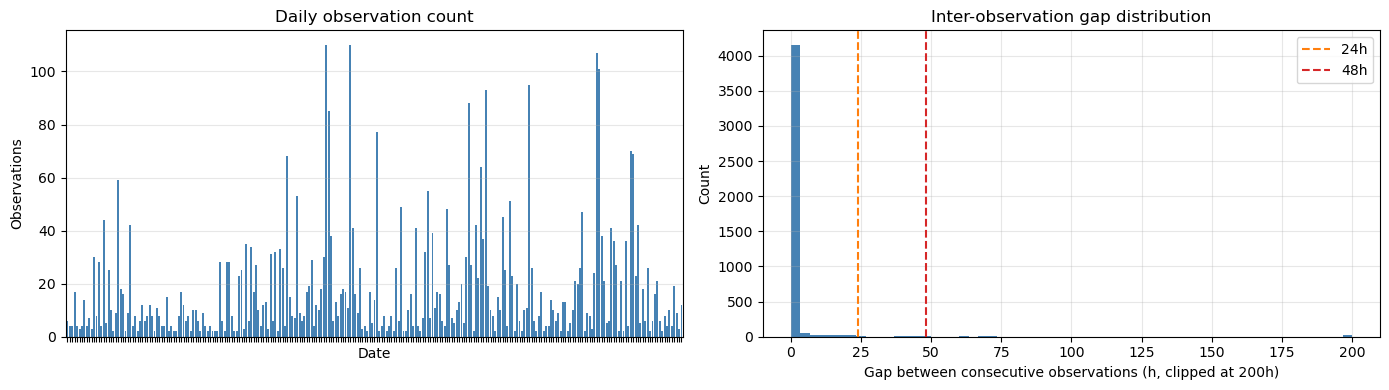

In [10]:
# =============================================================================
# BUILD OR RELOAD MASTER ML TABLE
# =============================================================================

REBUILD_MASTER_DF = True  # True = rebuild from current assembled table logic, False = load saved parquet

assembled_parquet = MODEL_OUT_DIR / f"ml_input_points_{interp_type}_binary_uncertainty.parquet"

required_predictors = FEATURES.copy()
required_cols = required_predictors + ["phase_full"]

if REBUILD_MASTER_DF:
    # -------------------------------------------------------------------------
    # Expect master_df to already exist from upstream assembly logic
    # -------------------------------------------------------------------------
    if "master_df" not in globals():
        raise NameError("master_df is not currently defined. Run the upstream assembly cell first.")

    missing_required = [c for c in required_cols if c not in master_df.columns]
    if missing_required:
        raise KeyError(f"Missing required columns after predictor assembly: {missing_required}")

    master_df = master_df.loc[:, ~master_df.columns.duplicated()].copy()
    master_df = master_df.dropna(subset=required_cols).copy()
    master_df["phase_full"] = master_df["phase_full"].astype(int)

    master_df.to_parquet(assembled_parquet, index=False)

    print("Saved assembled pointwise ML table to:", assembled_parquet)

else:
    # -------------------------------------------------------------------------
    # Reload previously saved version
    # -------------------------------------------------------------------------
    if not assembled_parquet.exists():
        raise FileNotFoundError(
            f"Saved master_df parquet not found:\n{assembled_parquet}\n"
            "Set REBUILD_MASTER_DF = True and rerun the upstream assembly first."
        )

    master_df = pd.read_parquet(assembled_parquet)

    missing_required = [c for c in required_cols if c not in master_df.columns]
    if missing_required:
        raise KeyError(f"Missing required columns after reload: {missing_required}")

    master_df = master_df.loc[:, ~master_df.columns.duplicated()].copy()
    master_df = master_df.dropna(subset=required_cols).copy()
    master_df["phase_full"] = master_df["phase_full"].astype(int)

    print("Loaded assembled pointwise ML table from:", assembled_parquet)

print("\nMaster table shape after dropna:", master_df.shape)
print("Class balance before blocking:")
print(master_df["phase_full"].value_counts(normalize=True).sort_index())

# =============================================================================
# TEMPORAL STRUCTURE DIAGNOSTIC
# =============================================================================

obs_times = pd.to_datetime(master_df["time"]).sort_values().reset_index(drop=True)

print("=== Observation time range ===")
print(f"  First: {obs_times.iloc[0]}")
print(f"  Last:  {obs_times.iloc[-1]}")
print(f"  Total: {len(obs_times)} observations")
print(f"  Span:  {(obs_times.iloc[-1] - obs_times.iloc[0]).days} days")

# Observations per day
obs_per_day = (
    master_df.assign(date=pd.to_datetime(master_df["time"]).dt.date)
    .groupby("date")
    .size()
    .rename("n_obs")
)
print(f"\n=== Daily observation counts ===")
print(f"  Days with any observations: {len(obs_per_day)}")
print(f"  Days with 0 observations:   "
      f"{(obs_times.iloc[-1] - obs_times.iloc[0]).days + 1 - len(obs_per_day)}")
print(f"  Mean obs/day (active days): {obs_per_day.mean():.1f}")
print(f"  Median obs/day:             {obs_per_day.median():.1f}")
print(f"  Max obs/day:                {obs_per_day.max()}")
print(f"  Percentiles (25/75/90/99):  "
      f"{obs_per_day.quantile(.25):.0f} / "
      f"{obs_per_day.quantile(.75):.0f} / "
      f"{obs_per_day.quantile(.90):.0f} / "
      f"{obs_per_day.quantile(.99):.0f}")

# Inter-observation gaps — what does the quiet period structure look like?
gaps_h = obs_times.diff().dt.total_seconds().dropna() / 3600
print(f"\n=== Inter-observation gaps ===")
print(f"  Median gap:   {gaps_h.median():.1f} h")
print(f"  Mean gap:     {gaps_h.mean():.1f} h")
print(f"  Gaps > 12h:   {(gaps_h > 12).sum()}")
print(f"  Gaps > 24h:   {(gaps_h > 24).sum()}")
print(f"  Gaps > 48h:   {(gaps_h > 48).sum()}")
print(f"  Gaps > 7d:    {(gaps_h > 168).sum()}")
print(f"  Max gap:      {gaps_h.max():.1f} h ({gaps_h.max()/24:.1f} days)")

# Phase balance by month — is there seasonal structure worth knowing about?
monthly = (
    master_df.assign(month=pd.to_datetime(master_df["time"]).dt.month)
    .groupby("month")["phase_full"]
    .value_counts(normalize=True)
    .unstack(fill_value=0.0)
    .round(3)
)
monthly.columns = ["snow", "rain", "mix"]
monthly.index = monthly.index.map({
    10:"Oct", 11:"Nov", 12:"Dec", 1:"Jan", 2:"Feb", 3:"Mar", 4:"Apr", 5:"May"
})
print(f"\n=== Phase balance by month ===")
print(monthly.to_string())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

obs_per_day.plot(ax=axes[0], kind="bar", color="steelblue", width=0.8)
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Observations")
axes[0].set_title("Daily observation count")
axes[0].tick_params(axis="x", labelbottom=False)
axes[0].grid(axis="y", alpha=0.3)

axes[1].hist(gaps_h.clip(upper=200), bins=60, color="steelblue", edgecolor="none")
axes[1].axvline(24,  color="tab:orange", ls="--", label="24h")
axes[1].axvline(48,  color="tab:red",    ls="--", label="48h")
axes[1].set_xlabel("Gap between consecutive observations (h, clipped at 200h)")
axes[1].set_ylabel("Count")
axes[1].set_title("Inter-observation gap distribution")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

In [11]:
# =============================================================================
# RANDOM TRAIN / VAL / TEST SPLIT
# =============================================================================
#
# Scientific justification
# ------------------------
# The binary model learns the relationship between instantaneous meteorological
# state variables (Twet, Tair, dewpoint, RH, elevation, IMERG PLP, PRISM Tair,
# LOOCV MRoS probabilities) and observed precipitation phase.  That relationship
# is physically stable across storm events — a given wet-bulb temperature predicts
# snow with the same probability regardless of the synoptic system producing it.
# A randomised split preserves the overall distribution of meteorological states
# and phase labels across train / val / test, which is the primary requirement
# for unbiased generalisation evaluation of a physics-based feature set.
#
# This approach is consistent with Jennings et al. (2025), who evaluated XGBoost
# on randomly split subsets of their crowdsourced and synoptic precipitation phase
# datasets without storm-event blocking.
#
# Known limitation
# ----------------
# Observations from the same storm event may appear in both train and test,
# which means test performance may be mildly optimistic relative to deployment
# on a genuinely novel future season.  Given the dataset size (6,150 observations
# spanning 82 active days) and sparse, opportunistic observation structure of the
# MRoS citizen science network, more complex event-based blocking would risk
# producing splits too small to support stable model fitting and calibration.
# This limitation is documented in the methodology.
#
# Split proportions: 70% train / 15% val / 15% test (by observation count).
# Fixed random seed for reproducibility.

from sklearn.model_selection import train_test_split

points_ml_df = pd.read_parquet(assembled_parquet)

print("Master table shape:", points_ml_df.shape)
print("\nClass balance:")
print(points_ml_df["phase_full"].value_counts(normalize=True).sort_index().round(4))

# ── Two-step stratified split: train vs (val+test), then val vs test ──────────
# Stratify on phase_full so each split preserves the overall snow/rain/mix ratio.

train_df, valtest_df = train_test_split(
    points_ml_df,
    test_size=1.0 - TRAIN_FRAC,
    random_state=RANDOM_SEED,
    stratify=points_ml_df["phase_full"],
)

# Split the remaining 30% evenly into val and test (each ~15% of total).
val_df, test_df = train_test_split(
    valtest_df,
    test_size=0.5,
    random_state=RANDOM_SEED,
    stratify=valtest_df["phase_full"],
)

train_df = train_df.copy()
val_df   = val_df.copy()
test_df  = test_df.copy()

train_df["split"] = "train"
val_df["split"]   = "val"
test_df["split"]  = "test"

best_blocked_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

# ── Summary ───────────────────────────────────────────────────────────────────
print("\nSplit proportions (rows):")
print(best_blocked_df["split"].value_counts(normalize=True).round(3))

print("\nClass balance by split:")
print(
    best_blocked_df.groupby("split")["phase_full"]
    .value_counts(normalize=True)
    .unstack(fill_value=0.0)
    .round(3)
)

split_parquet = SETUP_DIR / f"ml_input_points_{interp_type}_binary_uncertainty_random_split.parquet"
best_blocked_df.to_parquet(split_parquet, index=False)
blocked_parquet = split_parquet   # alias used by downstream cells
print("\nSaved split table to:", split_parquet)

Master table shape: (4441, 23)

Class balance:
phase_full
0    0.5519
1    0.2932
2    0.1549
Name: proportion, dtype: float64

Split proportions (rows):
split
train    0.70
test     0.15
val      0.15
Name: proportion, dtype: float64

Class balance by split:
phase_full      0      1      2
split                          
test        0.552  0.294  0.154
train       0.552  0.293  0.155
val         0.553  0.293  0.155

Saved split table to: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\ML_pipeline\compiled_input_predictors\CA\results_binaryXGB_withIDW\ml_input_points_IDW_binary_uncertainty_random_split.parquet


In [12]:
# =============================================================================
# SPLIT SUMMARY AND DIAGNOSTICS
# =============================================================================
#
# Verifies that the randomised stratified split preserved the phase balance
# and covers the full range of key predictors in each subset.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colors = {"train": "tab:blue", "val": "tab:orange", "test": "tab:red"}

# ── Phase balance by split ────────────────────────────────────────────────────
phase_balance = (
    best_blocked_df.groupby("split")["phase_full"]
    .value_counts(normalize=True)
    .unstack(fill_value=0.0)
    .rename(columns={0: "snow", 1: "rain", 2: "mix"})
)
phase_balance.plot(kind="bar", ax=axes[0], color=["#1f77b4", "#2ca02c", "#e377c2"],
                   edgecolor="k", linewidth=0.5)
axes[0].set_title("Phase balance by split")
axes[0].set_ylabel("Fraction")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(loc="upper right")
axes[0].grid(axis="y", alpha=0.3)

# ── Wet-bulb temperature distribution ────────────────────────────────────────
for split, grp in best_blocked_df.groupby("split"):
    axes[1].hist(grp["temp_wet"].dropna(), bins=30, alpha=0.5,
                 color=colors[split], label=split, density=True)
axes[1].set_xlabel("Wet-bulb temperature (°C)")
axes[1].set_ylabel("Density")
axes[1].set_title("Twet distribution by split\n(thermodynamic coverage check)")
axes[1].legend()
axes[1].grid(alpha=0.3)

# ── Elevation distribution ────────────────────────────────────────────────────
for split, grp in best_blocked_df.groupby("split"):
    axes[2].hist(grp["elev"].dropna(), bins=20, alpha=0.5,
                 color=colors[split], label=split, density=True)
axes[2].set_xlabel("Elevation (m)")
axes[2].set_ylabel("Density")
axes[2].set_title("Elevation distribution by split\n(spatial coverage check)")
axes[2].legend()
axes[2].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(
    GRAPHICS_DIR / f"random_split_diagnostics_{interp_type}.png",
    dpi=200, bbox_inches="tight",
)
plt.close(fig)
print(f"Saved: random_split_diagnostics_{interp_type}.png")

# ── Tabular summary ───────────────────────────────────────────────────────────
print("\nSplit sizes:")
for split in ["train", "val", "test"]:
    sub = best_blocked_df[best_blocked_df["split"] == split]
    print(f"  {split}: {len(sub)} rows  |  "
          f"Twet mean={sub['temp_wet'].mean():.2f}°C  |  "
          f"elev mean={sub['elev'].mean():.0f}m")

Saved: random_split_diagnostics_IDW.png

Split sizes:
  train: 3108 rows  |  Twet mean=-2.74°C  |  elev mean=1713m
  val: 666 rows  |  Twet mean=-2.47°C  |  elev mean=1734m
  test: 667 rows  |  Twet mean=-3.12°C  |  elev mean=1719m


In [13]:
# =============================================================================
# FEATURE MATRICES + OBJECTIVE-DRIVEN WEIGHTING
# =============================================================================

from sklearn.metrics import recall_score

TARGET_FULL      = "phase_full"
PURE_PHASE_CODES = [SNOW_CODE, RAIN_CODE]

train_df_full = best_blocked_df[best_blocked_df["split"] == "train"].copy()
val_df_full   = best_blocked_df[best_blocked_df["split"] == "val"].copy()
test_df_full  = best_blocked_df[best_blocked_df["split"] == "test"].copy()

train_df_fit = train_df_full[train_df_full[TARGET_FULL].isin(PURE_PHASE_CODES)].copy()
val_df_fit   = val_df_full[val_df_full[TARGET_FULL].isin(PURE_PHASE_CODES)].copy()
test_df_fit  = test_df_full[test_df_full[TARGET_FULL].isin(PURE_PHASE_CODES)].copy()

for name, df_ in [("train", train_df_fit), ("val", val_df_fit), ("test", test_df_fit)]:
    if df_.empty:
        raise ValueError(f"{name} pure-phase subset is empty. Cannot fit binary model.")

X_train = train_df_fit[FEATURES].copy()
X_val   = val_df_fit[FEATURES].copy()
X_test  = test_df_fit[FEATURES].copy()

X_val_full  = val_df_full[FEATURES].copy()
X_test_full = test_df_full[FEATURES].copy()

y_train = train_df_fit[TARGET_FULL].map(BINARY_LABEL_MAP).astype(int)
y_val   = val_df_fit[TARGET_FULL].map(BINARY_LABEL_MAP).astype(int)
y_test  = test_df_fit[TARGET_FULL].map(BINARY_LABEL_MAP).astype(int)

y_val_full_phase  = val_df_full[TARGET_FULL].astype(int).to_numpy()
y_test_full_phase = test_df_full[TARGET_FULL].astype(int).to_numpy()
y_val_fit_phase   = val_df_fit[TARGET_FULL].astype(int).to_numpy()
y_test_fit_phase  = test_df_fit[TARGET_FULL].astype(int).to_numpy()

print("\nTraining feature columns:")
print(FEATURES)

print("\nPure-phase fitting counts (rain/snow only):")
for name, df_ in [("Train", train_df_fit), ("Val", val_df_fit), ("Test", test_df_fit)]:
    print(f"{name}:\n", df_[TARGET_FULL].value_counts().sort_index())

if RUN_CORR_DIAGNOSTICS:
    corr = train_df_fit[FEATURES].corr(numeric_only=True)
    corr.to_csv(MODEL_OUT_DIR / "predictor_correlation_matrix.csv")

    high_corr = (
        corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
            .stack()
            .reset_index()
    )
    high_corr.columns = ["var1", "var2", "correlation"]
    high_corr["abs_correlation"] = high_corr["correlation"].abs()
    high_corr = high_corr.sort_values("abs_correlation", ascending=False)
    high_corr.to_csv(MODEL_OUT_DIR / "predictor_correlation_pairs.csv", index=False)
    print("\nTop correlated predictor pairs:")
    print(high_corr.head(15))


# =============================================================================
# OBJECTIVE-DRIVEN scale_pos_weight SWEEP
# =============================================================================

def sweep_scale_pos_weight(
    X_tr, y_tr, X_vl, y_vl,
    candidates, base_params,
    probe_rounds=200, early_stopping=20, random_seed=42,
):
    from sklearn.metrics import balanced_accuracy_score, f1_score

    dtrain = xgb.DMatrix(X_tr, label=y_tr, feature_names=list(X_tr.columns))
    dval   = xgb.DMatrix(X_vl, label=y_vl, feature_names=list(X_vl.columns))

    records = []
    for spw in candidates:
        p = {**base_params, "scale_pos_weight": spw, "seed": random_seed}
        probe = xgb.train(
            params=p, dtrain=dtrain, num_boost_round=probe_rounds,
            evals=[(dval, "val")], early_stopping_rounds=early_stopping,
            verbose_eval=False,
        )
        p_snow = probe.predict(dval)
        y_pred = (p_snow >= 0.5).astype(int)

        snow_rec = recall_score(y_vl, y_pred, pos_label=1, zero_division=0)
        rain_rec = recall_score(y_vl, y_pred, pos_label=0, zero_division=0)
        gap      = abs(snow_rec - rain_rec)

        records.append({
            "scale_pos_weight": spw,
            "snow_recall":       round(snow_rec, 4),
            "rain_recall":       round(rain_rec, 4),
            "recall_gap":        round(gap, 4),
            "balanced_accuracy": round(balanced_accuracy_score(y_vl, y_pred), 4),
            "macro_f1":          round(f1_score(y_vl, y_pred, average="macro",
                                                zero_division=0), 4),
        })

    return pd.DataFrame(records).sort_values("recall_gap").reset_index(drop=True)


BASE_XGB_PARAMS = {
    "objective":        "binary:logistic",
    "eval_metric":      "logloss",
    "max_depth":        6,
    "eta":              0.05,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "lambda":           1.0,
    "tree_method":      "hist",
}

print("\n" + "=" * 60)
print("scale_pos_weight sweep (probe rounds = 200)")
print("=" * 60)

spw_results = sweep_scale_pos_weight(
    X_tr=X_train, y_tr=y_train,
    X_vl=X_val,   y_vl=y_val,
    candidates=SCALE_POS_WEIGHT_GRID,
    base_params=BASE_XGB_PARAMS,
    probe_rounds=350, early_stopping=30, random_seed=RANDOM_SEED,
)

print(spw_results.to_string(index=False))

BEST_SCALE_POS_WEIGHT = float(spw_results.iloc[0]["scale_pos_weight"])
print(f"\nSelected scale_pos_weight: {BEST_SCALE_POS_WEIGHT}")
print(f"  Snow recall : {spw_results.iloc[0]['snow_recall']:.4f}")
print(f"  Rain recall : {spw_results.iloc[0]['rain_recall']:.4f}")
print(f"  Recall gap  : {spw_results.iloc[0]['recall_gap']:.4f}")

spw_results.to_csv(MODEL_OUT_DIR / "scale_pos_weight_sweep.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(spw_results["scale_pos_weight"], spw_results["snow_recall"],
             marker="o", label="snow recall")
axes[0].plot(spw_results["scale_pos_weight"], spw_results["rain_recall"],
             marker="o", label="rain recall")
axes[0].axvline(BEST_SCALE_POS_WEIGHT, ls="--", color="k", alpha=0.6,
                label=f"selected = {BEST_SCALE_POS_WEIGHT}")
axes[0].set_xlabel("scale_pos_weight"); axes[0].set_ylabel("Recall")
axes[0].set_title("Snow / rain recall vs scale_pos_weight")
axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(spw_results["scale_pos_weight"], spw_results["recall_gap"],
             marker="o", color="tab:red", label="|snow − rain recall|")
axes[1].axvline(BEST_SCALE_POS_WEIGHT, ls="--", color="k", alpha=0.6,
                label=f"selected = {BEST_SCALE_POS_WEIGHT}")
axes[1].set_xlabel("scale_pos_weight"); axes[1].set_ylabel("|Recall gap|")
axes[1].set_title("Recall gap vs scale_pos_weight")
axes[1].grid(alpha=0.3); axes[1].legend()

fig.tight_layout()
fig.savefig(GRAPHICS_DIR / f"scale_pos_weight_sweep_{interp_type}.png",
            dpi=200, bbox_inches="tight")
plt.close(fig)
print(f"Sweep plot saved: scale_pos_weight_sweep_{interp_type}.png")


Training feature columns:
['temp_air', 'temp_dew', 'temp_wet', 'imerg_plp', 'elev', 'mros_p_snow_loocv', 'mros_p_mix_loocv', 'mros_p_rain_loocv']

Pure-phase fitting counts (rain/snow only):
Train:
 phase_full
0    1715
1     911
Name: count, dtype: int64
Val:
 phase_full
0    368
1    195
Name: count, dtype: int64
Test:
 phase_full
0    368
1    196
Name: count, dtype: int64

Top correlated predictor pairs:
                 var1               var2  correlation  abs_correlation
26  mros_p_snow_loocv  mros_p_rain_loocv    -0.809857         0.809857
1            temp_air           temp_wet     0.734733         0.734733
8            temp_dew          imerg_plp     0.622269         0.622269
19          imerg_plp  mros_p_snow_loocv    -0.579806         0.579806
2            temp_air          imerg_plp     0.561422         0.561422
0            temp_air           temp_dew     0.557416         0.557416
10           temp_dew  mros_p_snow_loocv    -0.549161         0.549161
21          imerg_p

In [14]:
# =============================================================================
#  FIT FULL MODEL
# =============================================================================

params = {
    **BASE_XGB_PARAMS,
    "scale_pos_weight": BEST_SCALE_POS_WEIGHT,
    "seed": RANDOM_SEED,
}

dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=FEATURES)
dval   = xgb.DMatrix(X_val,   label=y_val,   feature_names=FEATURES)

evals        = [(dtrain, "train"), (dval, "val")]
evals_result = {}

booster = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=NUM_BOOST_ROUND,
    evals=evals,
    evals_result=evals_result,
    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
    verbose_eval=50,
)

print("\nBest iteration:", booster.best_iteration)
print("Best validation score:", booster.best_score)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(evals_result["train"]["logloss"], label="train")
ax.plot(evals_result["val"]["logloss"],   label="val")
ax.axvline(
    booster.best_iteration, ls="--", alpha=0.7,
    label=f"best={booster.best_iteration}",
)
ax.set_xlabel("Boosting iteration")
ax.set_ylabel("Binary log loss")
ax.set_title(
    f"XGBoost binary rain/snow logloss ({interp_type})"
    f"  [scale_pos_weight={BEST_SCALE_POS_WEIGHT}]"
)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(
    GRAPHICS_DIR / f"xgb_binary_logloss_{interp_type}.png",
    dpi=200, bbox_inches="tight",
)
plt.close(fig)

[0]	train-logloss:0.62092	val-logloss:0.62148
[50]	train-logloss:0.18653	val-logloss:0.21092
[100]	train-logloss:0.14669	val-logloss:0.19581
[136]	train-logloss:0.13232	val-logloss:0.19711

Best iteration: 86
Best validation score: 0.19543773108236426


In [15]:
# =============================================================================
# CALIBRATE + DERIVE UNCERTAINTY PRODUCT
# =============================================================================
#
# Calibration: K-fold cross-fitted isotonic regression, regime-stratified
# -----------------------------------------------------------------------
# With a randomised split there is no station or block structure to cross-fit
# over.  Instead, K-fold cross-fitting within the train+val pure-phase pool
# is used: the pool is divided into K folds, each fold is held out in turn,
# isotonic calibration is fitted on the remaining K-1 folds, and calibrated
# probabilities are predicted for the held-out fold.  This gives every
# observation in the train+val pool a calibrated probability estimated from
# independent data, and the final calibration models (fitted on the full
# train+val pool) are applied forward to the test set.
#
# Two regime-stratified calibration models are fitted separately:
#   - Clear phase  (|Twet| > CLEAR_PHASE_TWET_C): well-separated scores
#   - Near-freezing (|Twet| ≤ CLEAR_PHASE_TWET_C): scores compressed near 0.5
#
# Sigma grid bounded to (1.0, 1.5, 2.0) °C following Sims & Liu (2015) and
# Jennings et al. (2025).

from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import KFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, f1_score, log_loss, recall_score,
)


# =============================================================================
# HELPERS — REGIME-STRATIFIED ISOTONIC CALIBRATION
# =============================================================================

def fit_isotonic(probs_raw: np.ndarray, y_true: np.ndarray) -> IsotonicRegression:
    """Fit isotonic regression: raw p(snow) → calibrated p(snow)."""
    model = IsotonicRegression(out_of_bounds="clip")
    model.fit(probs_raw, y_true)
    return model


def apply_isotonic(model: IsotonicRegression, probs_raw: np.ndarray) -> np.ndarray:
    return model.predict(probs_raw)


def kfold_isotonic_calibration(
    train_val_df_fit: pd.DataFrame,
    booster,
    features: list[str],
    binary_label_col: str = "phase_binary",
    twet_col: str = "temp_wet",
    clear_phase_twet: float = 2.0,
    n_splits: int = 10,
    random_state: int = 42,
) -> tuple[dict, np.ndarray]:
    """
    K-fold cross-fitted isotonic calibration, stratified by temperature regime.

    The train+val pure-phase pool is divided into n_splits folds.  For each
    fold, isotonic calibration models (one per temperature regime) are fitted
    on the remaining folds and applied to the held-out fold.  This gives every
    observation a calibrated probability estimated from data it wasn't part of.

    Two final calibration models — fitted on all train+val data — are returned
    for forward application to the test set.

    Parameters
    ----------
    train_val_df_fit  : DataFrame with features, binary label, temp_wet
    booster           : fitted xgb.Booster
    features          : feature column names
    binary_label_col  : column holding 0/1 binary snow label
    twet_col          : wet-bulb temperature column (°C)
    clear_phase_twet  : |Twet| boundary separating regimes (°C)
    n_splits          : number of K-fold splits (default 10)

    Returns
    -------
    final_cal_models  : dict with keys "clear" and "near_freezing"
    cross_fitted_probs: np.ndarray of cross-fitted calibrated p(snow), all rows
    """
    df    = train_val_df_fit.reset_index(drop=True)
    n     = len(df)
    y_all = df[binary_label_col].values
    tw_all = df[twet_col].values

    # Raw probabilities from booster for all train+val rows
    d_all     = xgb.DMatrix(df[features], feature_names=features)
    p_all_raw = booster.predict(d_all)

    cf_probs = np.full(n, np.nan)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    print(f"  K-fold isotonic calibration: {n_splits} folds, "
          f"n={n} train+val pure-phase rows")

    for fold_idx, (rest_idx, held_idx) in enumerate(kf.split(np.arange(n))):
        p_rest = p_all_raw[rest_idx]
        y_rest = y_all[rest_idx]
        tw_rest = tw_all[rest_idx]

        p_held  = p_all_raw[held_idx]
        tw_held = tw_all[held_idx]

        p_held_cal = p_held.copy()   # fallback: raw

        clear_rest = np.abs(tw_rest) > clear_phase_twet
        nf_rest    = ~clear_rest
        clear_held = np.abs(tw_held) > clear_phase_twet
        nf_held    = ~clear_held

        if clear_rest.sum() >= 10 and clear_held.sum() > 0:
            cal_clear = fit_isotonic(p_rest[clear_rest], y_rest[clear_rest])
            p_held_cal[clear_held] = apply_isotonic(cal_clear, p_held[clear_held])

        if nf_rest.sum() >= 10 and nf_held.sum() > 0:
            cal_nf = fit_isotonic(p_rest[nf_rest], y_rest[nf_rest])
            p_held_cal[nf_held] = apply_isotonic(cal_nf, p_held[nf_held])

        cf_probs[held_idx] = p_held_cal

    n_filled = int(np.sum(~np.isnan(cf_probs)))
    print(f"  Cross-fitting complete: {n_filled}/{n} rows calibrated.")

    if np.any(np.isnan(cf_probs)):
        cf_probs[np.isnan(cf_probs)] = 0.5
        warnings.warn("Some rows received no cross-fitted calibration — filled with 0.5.",
                      stacklevel=2)

    # ── Final calibration models on full train+val pool ───────────────────────
    clear_all = np.abs(tw_all) > clear_phase_twet
    nf_all    = ~clear_all

    final_cal_models = {}

    if clear_all.sum() >= 10:
        final_cal_models["clear"] = fit_isotonic(
            p_all_raw[clear_all], y_all[clear_all]
        )
        print(f"  Final clear-phase model:       "
              f"n={clear_all.sum()} (|Twet| > {clear_phase_twet}°C)")
    else:
        warnings.warn("Insufficient clear-phase data for final calibration model.",
                      stacklevel=2)

    if nf_all.sum() >= 10:
        final_cal_models["near_freezing"] = fit_isotonic(
            p_all_raw[nf_all], y_all[nf_all]
        )
        print(f"  Final near-freezing model:     "
              f"n={nf_all.sum()} (|Twet| ≤ {clear_phase_twet}°C)")
    else:
        warnings.warn("Insufficient near-freezing data for final calibration model.",
                      stacklevel=2)

    return final_cal_models, cf_probs


def apply_regime_calibration(
    probs_raw: np.ndarray,
    temp_wet: np.ndarray,
    cal_models: dict,
    clear_phase_twet: float = 2.0,
) -> np.ndarray:
    """Apply regime-stratified isotonic calibration to raw probabilities."""
    probs_raw = np.asarray(probs_raw, dtype=float)
    tw        = np.asarray(temp_wet,  dtype=float)
    out       = probs_raw.copy()

    clear = np.abs(tw) > clear_phase_twet
    nf    = ~clear

    if "clear" in cal_models and clear.any():
        out[clear] = apply_isotonic(cal_models["clear"], probs_raw[clear])
    if "near_freezing" in cal_models and nf.any():
        out[nf] = apply_isotonic(cal_models["near_freezing"], probs_raw[nf])

    return out


# =============================================================================
# HELPERS — WET-BULB-CONDITIONED GAUSSIAN HALF-BAND
# =============================================================================

def gaussian_half_band(
    temp_wet: np.ndarray,
    base_half_band: float,
    extra_half_band: float,
    sigma: float,
) -> np.ndarray:
    t  = np.asarray(temp_wet, dtype=float)
    hb = base_half_band + extra_half_band * np.exp(-(t ** 2) / (2.0 * sigma ** 2))
    return np.clip(hb, 0.0, 0.5)


def classify_phase_gaussian_band(
    p_snow: np.ndarray,
    temp_wet: np.ndarray,
    base_half_band: float,
    extra_half_band: float,
    sigma: float,
) -> np.ndarray:
    p_snow = np.asarray(p_snow, dtype=float)
    hb     = gaussian_half_band(temp_wet, base_half_band, extra_half_band, sigma)
    pred   = np.full(len(p_snow), MIX_CODE, dtype=int)
    pred[p_snow <= 0.5 - hb] = RAIN_CODE
    pred[p_snow >= 0.5 + hb] = SNOW_CODE
    return pred


def optimize_threshold_params(
    p_snow_cal: np.ndarray,
    temp_wet: np.ndarray,
    y_true_phase: np.ndarray,
    base_half_band_grid=BASE_HALF_BAND_GRID,
    extra_half_band_grid=EXTRA_HALF_BAND_GRID,
    sigma_grid=SIGMA_GRID,
    min_pure_coverage=MIN_PURE_COVERAGE,
    mix_capture_weight=MIX_CAPTURE_WEIGHT,
) -> dict:
    p_snow = np.asarray(p_snow_cal,   dtype=float)
    t_wet  = np.asarray(temp_wet,     dtype=float)
    y_true = np.asarray(y_true_phase, dtype=int)

    true_mix  = y_true == MIX_CODE
    true_pure = np.isin(y_true, [SNOW_CODE, RAIN_CODE])

    records = []
    for base_hb, extra_hb, sigma in itertools.product(
        base_half_band_grid, extra_half_band_grid, sigma_grid
    ):
        if base_hb + extra_hb >= MAX_TOTAL_HALF_BAND:
            continue

        pred      = classify_phase_gaussian_band(p_snow, t_wet, base_hb, extra_hb, sigma)
        pred_mix  = pred == MIX_CODE
        pred_conf = pred != MIX_CODE

        mix_capture  = pred_mix[true_mix].mean()   if true_mix.any()  else np.nan
        pure_cov     = pred_conf[true_pure].mean()  if true_pure.any() else np.nan
        mask_cp      = true_pure & pred_conf
        pure_conf_acc = (pred[mask_cp] == y_true[mask_cp]).mean() if mask_cp.any() else np.nan

        composite = (
            mix_capture_weight * mix_capture
            + (1.0 - mix_capture_weight) * pure_conf_acc
            if not (np.isnan(mix_capture) or np.isnan(pure_conf_acc)) else np.nan
        )

        feasible    = (not np.isnan(pure_cov)) and (pure_cov >= min_pure_coverage)
        nf_pure     = true_pure & (np.abs(t_wet) <= 1.0)
        nf_cov      = pred_conf[nf_pure].mean() if nf_pure.any() else np.nan
        nf_feasible = (not np.isnan(nf_cov)) and (nf_cov >= MIN_NF_PURE_COVERAGE)
        feasible    = feasible and nf_feasible

        records.append({
            "base_half_band":    base_hb,
            "extra_half_band":   extra_hb,
            "sigma":             sigma,
            "rain_thresh_0C":    round(0.5 - (base_hb + extra_hb), 4),
            "snow_thresh_0C":    round(0.5 + (base_hb + extra_hb), 4),
            "rain_thresh_far":   round(0.5 - base_hb, 4),
            "snow_thresh_far":   round(0.5 + base_hb, 4),
            "mix_capture_rate":  mix_capture,
            "pure_coverage":     pure_cov,
            "pure_conf_accuracy":pure_conf_acc,
            "composite_score":   composite,
            "feasible":          feasible,
        })

    results_df = pd.DataFrame(records).sort_values(
        ["feasible", "composite_score"], ascending=[False, False]
    ).reset_index(drop=True)

    feasible_df = results_df[results_df["feasible"]]
    best = feasible_df.iloc[0] if not feasible_df.empty else results_df.iloc[0]
    if feasible_df.empty:
        warnings.warn("No feasible parameter combination found. "
                      "Returning best unconstrained result.", stacklevel=2)

    print("\n=== THRESHOLD OPTIMISATION RESULTS ===")
    for k in ["base_half_band", "extra_half_band", "sigma",
              "rain_thresh_0C", "snow_thresh_0C", "rain_thresh_far", "snow_thresh_far",
              "mix_capture_rate", "pure_coverage", "pure_conf_accuracy", "composite_score"]:
        print(f"  {k:28s}: {best[k]:.4f}")

    return {
        "base_half_band":     float(best["base_half_band"]),
        "extra_half_band":    float(best["extra_half_band"]),
        "sigma":              float(best["sigma"]),
        "rain_thresh_0C":     float(best["rain_thresh_0C"]),
        "snow_thresh_0C":     float(best["snow_thresh_0C"]),
        "rain_thresh_far":    float(best["rain_thresh_far"]),
        "snow_thresh_far":    float(best["snow_thresh_far"]),
        "composite_score":    float(best["composite_score"]),
        "mix_capture_rate":   float(best["mix_capture_rate"]),
        "pure_conf_accuracy": float(best["pure_conf_accuracy"]),
        "pure_coverage":      float(best["pure_coverage"]),
        "all_results":        results_df,
    }


def transition_score_from_psnow(p_snow: np.ndarray) -> np.ndarray:
    return 1.0 - np.abs(2.0 * np.asarray(p_snow) - 1.0)


# =============================================================================
# STEP 1 — K-FOLD CROSS-FITTED ISOTONIC CALIBRATION
# =============================================================================

print("=" * 60)
print("STEP 1: K-fold isotonic calibration (regime-stratified)")
print("=" * 60)

train_val_fit_df = pd.concat(
    [
        train_df_fit.assign(phase_binary=y_train.values),
        val_df_fit.assign(phase_binary=y_val.values),
    ],
    ignore_index=True,
)
print(f"Train+val pure-phase pool: {len(train_val_fit_df)} rows")

final_cal_models, _ = kfold_isotonic_calibration(
    train_val_df_fit=train_val_fit_df,
    booster=booster,
    features=FEATURES,
    binary_label_col="phase_binary",
    twet_col="temp_wet",
    clear_phase_twet=CLEAR_PHASE_TWET_C,
    n_splits=10,
    random_state=RANDOM_SEED,
)

# ── Raw probabilities and margins ─────────────────────────────────────────────
dval_fit   = xgb.DMatrix(X_val,       feature_names=FEATURES)
dtest_fit  = xgb.DMatrix(X_test,      feature_names=FEATURES)
dval_full  = xgb.DMatrix(X_val_full,  feature_names=FEATURES)
dtest_full = xgb.DMatrix(X_test_full, feature_names=FEATURES)

val_fit_prob_raw    = booster.predict(dval_fit)
test_fit_prob_raw   = booster.predict(dtest_fit)
val_full_prob_raw   = booster.predict(dval_full)
test_full_prob_raw  = booster.predict(dtest_full)

val_fit_margin_raw  = booster.predict(dval_fit,   output_margin=True)
test_fit_margin_raw = booster.predict(dtest_fit,  output_margin=True)
val_full_margin_raw = booster.predict(dval_full,  output_margin=True)
test_full_margin_raw= booster.predict(dtest_full, output_margin=True)

# ── Apply regime-stratified calibration ──────────────────────────────────────
val_fit_prob_cal  = apply_regime_calibration(
    val_fit_prob_raw,   val_df_fit["temp_wet"].to_numpy(),  final_cal_models, CLEAR_PHASE_TWET_C)
test_fit_prob_cal = apply_regime_calibration(
    test_fit_prob_raw,  test_df_fit["temp_wet"].to_numpy(), final_cal_models, CLEAR_PHASE_TWET_C)
val_full_prob_cal = apply_regime_calibration(
    val_full_prob_raw,  val_df_full["temp_wet"].to_numpy(), final_cal_models, CLEAR_PHASE_TWET_C)
test_full_prob_cal= apply_regime_calibration(
    test_full_prob_raw, test_df_full["temp_wet"].to_numpy(),final_cal_models, CLEAR_PHASE_TWET_C)

val_fit_p_rain_cal   = 1.0 - val_fit_prob_cal
test_fit_p_rain_cal  = 1.0 - test_fit_prob_cal
val_full_p_rain_cal  = 1.0 - val_full_prob_cal
test_full_p_rain_cal = 1.0 - test_full_prob_cal


# =============================================================================
# STEP 2 — OPTIMISE WET-BULB-CONDITIONED GAUSSIAN HALF-BAND
# =============================================================================

print("\n" + "=" * 60)
print("STEP 2: Gaussian half-band threshold optimisation")
print(f"  Sigma grid: {SIGMA_GRID} °C  (Sims & Liu 2015; Jennings 2025)")
print("=" * 60)

threshold_result = optimize_threshold_params(
    p_snow_cal=val_full_prob_cal,
    temp_wet=val_df_full["temp_wet"].to_numpy(),
    y_true_phase=y_val_full_phase,
)

BEST_BASE_HB  = threshold_result["base_half_band"]
BEST_EXTRA_HB = threshold_result["extra_half_band"]
BEST_SIGMA    = threshold_result["sigma"]

threshold_result["all_results"].to_csv(
    MODEL_OUT_DIR / "threshold_optimisation_all_results.csv", index=False)
threshold_result["all_results"].head(10).to_csv(
    MODEL_OUT_DIR / "threshold_optimisation_top10.csv", index=False)

# Band shape plot
twet_range = np.linspace(-8, 8, 200)
hb_range   = gaussian_half_band(twet_range, BEST_BASE_HB, BEST_EXTRA_HB, BEST_SIGMA)

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(twet_range, 0.5 - hb_range, 0.5 + hb_range,
                alpha=0.25, color="tab:purple", label="mix / uncertain band")
ax.plot(twet_range, 0.5 - hb_range, color="tab:purple", lw=1.5)
ax.plot(twet_range, 0.5 + hb_range, color="tab:purple", lw=1.5)
ax.axhline(0.5, ls=":", color="k", alpha=0.4)
ax.axvline(0.0, ls="--", color="k", alpha=0.4, label="Twet = 0°C")
ax.axvline( CLEAR_PHASE_TWET_C, ls=":", color="gray", alpha=0.6,
            label=f"calibration regime ±{CLEAR_PHASE_TWET_C}°C")
ax.axvline(-CLEAR_PHASE_TWET_C, ls=":", color="gray", alpha=0.6)
ax.set_xlabel("Wet-bulb temperature (°C)")
ax.set_ylabel("p(snow) threshold")
ax.set_title(f"Gaussian half-band  |  base={BEST_BASE_HB:.2f}, "
             f"extra={BEST_EXTRA_HB:.2f}, σ={BEST_SIGMA:.1f}°C")
ax.set_ylim(0, 1); ax.grid(alpha=0.3); ax.legend()
fig.tight_layout()
fig.savefig(GRAPHICS_DIR / f"gaussian_halfband_shape_{interp_type}.png",
            dpi=200, bbox_inches="tight")
plt.close(fig)
print(f"Band shape plot saved.")


# =============================================================================
# APPLY THRESHOLDS
# =============================================================================

val_fit_pred_binary  = np.where(val_fit_prob_cal  >= 0.5, SNOW_CODE, RAIN_CODE)
test_fit_pred_binary = np.where(test_fit_prob_cal >= 0.5, SNOW_CODE, RAIN_CODE)

for name, p_cal, tw, df_ref in [
    ("val_full",  val_full_prob_cal,  val_df_full["temp_wet"].to_numpy(),  None),
    ("test_full", test_full_prob_cal, test_df_full["temp_wet"].to_numpy(), None),
    ("val_fit",   val_fit_prob_cal,   val_df_fit["temp_wet"].to_numpy(),   None),
    ("test_fit",  test_fit_prob_cal,  test_df_fit["temp_wet"].to_numpy(),  None),
]:
    globals()[f"{name}_pred_phase"] = classify_phase_gaussian_band(
        p_cal, tw, BEST_BASE_HB, BEST_EXTRA_HB, BEST_SIGMA)
    globals()[f"{name}_transition_score"] = transition_score_from_psnow(p_cal)

val_fit_entropy   = entropy(np.vstack([val_fit_p_rain_cal,   val_fit_prob_cal]),   base=2)
test_fit_entropy  = entropy(np.vstack([test_fit_p_rain_cal,  test_fit_prob_cal]),  base=2)
val_full_entropy  = entropy(np.vstack([val_full_p_rain_cal,  val_full_prob_cal]),  base=2)
test_full_entropy = entropy(np.vstack([test_full_p_rain_cal, test_full_prob_cal]), base=2)


# =============================================================================
# QUICK EVALUATION PRINTOUT
# =============================================================================

print("\n=== BINARY EVALUATION (pure-phase test, 0.5 threshold) ===")
print(confusion_matrix(y_test_fit_phase, test_fit_pred_binary,
                        labels=[SNOW_CODE, RAIN_CODE]))
print(classification_report(
    y_test_fit_phase, test_fit_pred_binary,
    labels=[SNOW_CODE, RAIN_CODE],
    target_names=["snow", "rain"], digits=3, zero_division=0,
))

print("\n=== UNCERTAINTY-DERIVED 3-CLASS (full test) ===")
print(confusion_matrix(y_test_full_phase, test_full_pred_phase,
                        labels=[SNOW_CODE, RAIN_CODE, MIX_CODE]))
print(classification_report(
    y_test_full_phase, test_full_pred_phase,
    labels=[SNOW_CODE, RAIN_CODE, MIX_CODE],
    target_names=FULL_CLASS_NAMES, digits=3, zero_division=0,
))

print(f"\nPure-phase test macro F1:        "
      f"{f1_score(y_test_fit_phase, test_fit_pred_binary, average='macro'):.4f}")
print(f"Pure-phase test calibrated log loss: "
      f"{log_loss(y_test.to_numpy(), test_fit_prob_cal, labels=[0, 1]):.4f}")


# =============================================================================
# ATTACH PREDICTIONS TO DATAFRAMES
# =============================================================================

def _attach_preds(base_df, p_snow_raw, p_snow_cal, pred_binary05,
                  pred_phase, transition_score, entropy_binary, raw_margin):
    df = base_df.copy()
    df["p_snow_raw"]                   = p_snow_raw
    df["p_snow_cal"]                   = p_snow_cal
    df["p_rain_raw"]                   = 1.0 - p_snow_raw
    df["p_rain_cal"]                   = 1.0 - p_snow_cal
    df["prediction_binary05"]          = pred_binary05
    df["prediction_phase_uncertainty"] = pred_phase
    df["transition_score"]             = transition_score
    df["entropy_binary"]               = entropy_binary
    df["raw_margin"]                   = raw_margin
    df["is_confident"]                 = pred_phase != MIX_CODE
    df["near_freezing_air_1C"]         = df["temp_air"].abs() <= 1.0
    df["near_freezing_wet_1C"]         = df["temp_wet"].abs() <= 1.0
    return df


df_val_fit = _attach_preds(
    val_df_fit, val_fit_prob_raw, val_fit_prob_cal,
    val_fit_pred_binary, val_fit_pred_phase,
    val_fit_transition_score, val_fit_entropy, val_fit_margin_raw)
df_val_fit["phase_binary"] = y_val.values

df_test_fit = _attach_preds(
    test_df_fit, test_fit_prob_raw, test_fit_prob_cal,
    test_fit_pred_binary, test_fit_pred_phase,
    test_fit_transition_score, test_fit_entropy, test_fit_margin_raw)
df_test_fit["phase_binary"] = y_test.values

df_val_full = _attach_preds(
    val_df_full, val_full_prob_raw, val_full_prob_cal,
    np.where(val_full_prob_cal >= 0.5, SNOW_CODE, RAIN_CODE),
    val_full_pred_phase, val_full_transition_score,
    val_full_entropy, val_full_margin_raw)

df_test_full = _attach_preds(
    test_df_full, test_full_prob_raw, test_full_prob_cal,
    np.where(test_full_prob_cal >= 0.5, SNOW_CODE, RAIN_CODE),
    test_full_pred_phase, test_full_transition_score,
    test_full_entropy, test_full_margin_raw)

print("\nDataframes ready: df_val_fit, df_test_fit, df_val_full, df_test_full")

STEP 1: K-fold isotonic calibration (regime-stratified)
Train+val pure-phase pool: 3189 rows
  K-fold isotonic calibration: 10 folds, n=3189 train+val pure-phase rows
  Cross-fitting complete: 3189/3189 rows calibrated.
  Final clear-phase model:       n=1969 (|Twet| > 2.0°C)
  Final near-freezing model:     n=1220 (|Twet| ≤ 2.0°C)

STEP 2: Gaussian half-band threshold optimisation
  Sigma grid: (1.0, 1.5, 2.0) °C  (Sims & Liu 2015; Jennings 2025)

=== THRESHOLD OPTIMISATION RESULTS ===
  base_half_band              : 0.2000
  extra_half_band             : 0.1500
  sigma                       : 2.0000
  rain_thresh_0C              : 0.1500
  snow_thresh_0C              : 0.8500
  rain_thresh_far             : 0.3000
  snow_thresh_far             : 0.7000
  mix_capture_rate            : 0.3786
  pure_coverage               : 0.8881
  pure_conf_accuracy          : 0.9640
  composite_score             : 0.6713
Band shape plot saved.

=== BINARY EVALUATION (pure-phase test, 0.5 threshold) 

In [16]:
# =============================================================================
# EXPORT
# =============================================================================

import json
import pickle

# ── Core model artifacts ──────────────────────────────────────────────────────
booster.save_model(MODEL_OUT_DIR / "xgb_binary_phase_model.bin")

with open(MODEL_OUT_DIR / "isotonic_calibration_models.pkl", "wb") as f:
    pickle.dump(final_cal_models, f)

with open(MODEL_OUT_DIR / "feature_names.json", "w") as f:
    json.dump(FEATURES, f, indent=2)

with open(MODEL_OUT_DIR / "training_evals_result.json", "w") as f:
    json.dump(evals_result, f, indent=2)

training_summary = {
    "best_iteration":       int(booster.best_iteration),
    "best_score":           float(booster.best_score),
    "num_boost_round":      int(NUM_BOOST_ROUND),
    "early_stopping_rounds":int(EARLY_STOPPING_ROUNDS),
}
with open(MODEL_OUT_DIR / "training_summary.json", "w") as f:
    json.dump(training_summary, f, indent=2)

calibration_summary = {
    "method": "kfold_regime_stratified_isotonic",
    "description": (
        "K-fold cross-fitted isotonic regression calibration applied to raw "
        "XGBoost probabilities. Calibration is stratified by wet-bulb temperature "
        "regime: clear phase (|Twet| > threshold) and near-freezing (|Twet| ≤ threshold). "
        "Final models are fit on the full train+val pool and applied to test data."
    ),
    "fit_subset": "train+val pure-phase observations",
    "input": "raw XGBoost probability p(snow)",
    "regimes": {
        "clear_phase_threshold_degC": CLEAR_PHASE_TWET_C,
        "models_present": list(final_cal_models.keys()),
        "n_clear_phase": int(np.sum(np.abs(train_val_fit_df["temp_wet"]) > CLEAR_PHASE_TWET_C)),
        "n_near_freezing": int(np.sum(np.abs(train_val_fit_df["temp_wet"]) <= CLEAR_PHASE_TWET_C)),
    },
    "model_type": "IsotonicRegression (non-parametric, monotonic)",
    "uncertainty_thresholds": {
        "method": "wet_bulb_conditioned_gaussian_half_band",
        "description": (
            "half_band(Twet) = base_half_band "
            "+ extra_half_band * exp(-Twet^2 / (2*sigma^2)); "
            "rain_thresh = 0.5 - half_band; snow_thresh = 0.5 + half_band. "
            "Parameters optimised on full validation set (including observed mix). "
            "Physical basis: Harder & Pomeroy (2013); Sims & Liu (2015); "
            "Jennings et al. (2018, 2023, 2025)."
        ),
        "base_half_band":       BEST_BASE_HB,
        "extra_half_band":      BEST_EXTRA_HB,
        "sigma_degC":           BEST_SIGMA,
        "rain_thresh_at_0C":    threshold_result["rain_thresh_0C"],
        "snow_thresh_at_0C":    threshold_result["snow_thresh_0C"],
        "rain_thresh_far":      threshold_result["rain_thresh_far"],
        "snow_thresh_far":      threshold_result["snow_thresh_far"],
        "optimisation_objective":"composite (mix_capture + pure_conf_accuracy, "
                                  f"weight={MIX_CAPTURE_WEIGHT}/{1-MIX_CAPTURE_WEIGHT})",
        "min_pure_coverage_constraint": MIN_PURE_COVERAGE,
        "val_mix_capture_rate":  threshold_result["mix_capture_rate"],
        "val_pure_conf_accuracy":threshold_result["pure_conf_accuracy"],
        "val_pure_coverage":     threshold_result["pure_coverage"],
    },
}

with open(MODEL_OUT_DIR / "calibration_summary.json", "w") as f:
    json.dump(calibration_summary, f, indent=2)

# ── Validation exports ────────────────────────────────────────────────────────
X_val.to_parquet(MODEL_OUT_DIR / "X_val_fit.parquet")
pd.Series(y_val, name="phase_binary").to_frame().to_parquet(
    MODEL_OUT_DIR / "y_val_fit_binary.parquet"
)
df_val_fit.to_parquet(MODEL_OUT_DIR / "val_fit_binary_predictions_combined.parquet")
df_val_full.to_parquet(MODEL_OUT_DIR / "val_full_uncertainty_predictions_combined.parquet")

_OUT_COLS = [
    "time", "x", "y", "phase_full", "prediction_binary05",
    "prediction_phase_uncertainty", "near_freezing_air_1C", "near_freezing_wet_1C",
    "p_snow_raw", "p_snow_cal", "p_rain_raw", "p_rain_cal",
    "transition_score", "entropy_binary", "raw_margin", "is_confident",
]

df_val_fit[_OUT_COLS].rename(columns={"phase_full": "phase"}).to_parquet(
    MODEL_OUT_DIR / "val_fit_binary_predictions.parquet"
)
df_val_full[_OUT_COLS].rename(columns={"phase_full": "phase"}).to_parquet(
    MODEL_OUT_DIR / "val_full_uncertainty_predictions.parquet"
)

# ── Test exports ──────────────────────────────────────────────────────────────
X_test.to_parquet(MODEL_OUT_DIR / "X_test_fit.parquet")
pd.Series(y_test, name="phase_binary").to_frame().to_parquet(
    MODEL_OUT_DIR / "y_test_fit_binary.parquet"
)
df_test_fit.to_parquet(MODEL_OUT_DIR / "test_fit_binary_predictions_combined.parquet")
df_test_full.to_parquet(MODEL_OUT_DIR / "test_full_uncertainty_predictions_combined.parquet")

df_test_fit[_OUT_COLS].rename(columns={"phase_full": "phase"}).to_parquet(
    MODEL_OUT_DIR / "test_fit_binary_predictions.parquet"
)
df_test_full[_OUT_COLS].rename(columns={"phase_full": "phase"}).to_parquet(
    MODEL_OUT_DIR / "test_full_uncertainty_predictions.parquet"
)

# ── Threshold optimisation audit trail ───────────────────────────────────────
threshold_result["all_results"].to_csv(
    MODEL_OUT_DIR / "threshold_optimisation_all_results.csv", index=False
)

# ── Full metadata ─────────────────────────────────────────────────────────────
metadata = {
    "version": "v6_binary_uncertainty",
    "classes_full":   {"0": "snow", "1": "rain", "2": "mix"},
    "classes_binary_fit": {"0": "rain", "1": "snow"},
    "model_type": (
        "XGBoost (binary:logistic) + regime-stratified K-fold isotonic calibration "
        "+ wet-bulb-conditioned Gaussian half-band uncertainty product"
    ),
    "interpolation_type": interp_type,
    "xgboost_params": params,
    "label_source": "raw MRoS categorical observations",
    "training_target_definition": (
        "Only observed rain/snow used for supervised binary fitting; "
        "observed mix excluded from fitting and retained for downstream "
        "uncertainty evaluation."
    ),
    "calibration": calibration_summary,
    "uncertainty_product": {
        "type": "wet-bulb-conditioned Gaussian half-band on calibrated p(snow)",
        "half_band_formula": (
            "half_band(Twet) = base_half_band "
            "+ extra_half_band * exp(-Twet^2 / (2*sigma^2))"
        ),
        "rain_if":  "p_snow_cal <= 0.5 - half_band(Twet)",
        "mix_if":   "0.5 - half_band(Twet) < p_snow_cal < 0.5 + half_band(Twet)",
        "snow_if":  "p_snow_cal >= 0.5 + half_band(Twet)",
        "references": [
            "Harder & Pomeroy (2013) Hydrol. Process.",
            "Sims & Liu (2015) J. Hydrometeorol.",
            "Jennings et al. (2018) Nat. Commun.",
            "Jennings et al. (2023) Earth Space Sci.",
            "Jennings et al. (2025) Nat. Commun.",
        ],
    },
    "weighting": {
        "method": "objective_driven_scale_pos_weight",
        "description": (
            "scale_pos_weight swept over a grid; value minimising "
            "|snow_recall - rain_recall| on the pure-phase validation subset selected."
        ),
        "scale_pos_weight_grid":    SCALE_POS_WEIGHT_GRID,
        "best_scale_pos_weight":    BEST_SCALE_POS_WEIGHT,
        "sweep_results_csv":        str(MODEL_OUT_DIR / "scale_pos_weight_sweep.csv"),
    },
    "mros_predictor_source": "LOOCV-safe MRoS support indicators at raw observation points",
    "predictor_sources": {
        "interp_grid": str(interp_grid_path),
        "mros_loocv":  str(loocv_path),
        "imerg":       str(imerg_path),
        # "prism":       str(prism_path),
    },
    "input_tables": {
        "assembled_ml_table": str(assembled_parquet),
        "blocked_ml_table":   str(blocked_parquet),
    },
    "features": FEATURES,
    "training_summary": training_summary,
    "graphics": {
        "training_logloss":       str(GRAPHICS_DIR / f"xgb_binary_logloss_{interp_type}.png"),
        "scale_pos_weight_sweep": str(GRAPHICS_DIR / f"scale_pos_weight_sweep_{interp_type}.png"),
        "gaussian_band_shape":    str(GRAPHICS_DIR / f"gaussian_halfband_shape_{interp_type}.png"),
    },
    "split_class_counts_full": {
        "train": train_df_full[TARGET_FULL].value_counts().sort_index().to_dict(),
        "val":   val_df_full[TARGET_FULL].value_counts().sort_index().to_dict(),
        "test":  test_df_full[TARGET_FULL].value_counts().sort_index().to_dict(),
    },
    "split_class_counts_fit": {
        "train": train_df_fit[TARGET_FULL].value_counts().sort_index().to_dict(),
        "val":   val_df_fit[TARGET_FULL].value_counts().sort_index().to_dict(),
        "test":  test_df_fit[TARGET_FULL].value_counts().sort_index().to_dict(),
    },
    "methodology_notes": [
        "No interpolated MRoS surface is used as a label.",
        "Raw MRoS observations provide the supervised target.",
        "Observed mix is not forced as a crisp learnable class during fitting.",
        "LOOCV-safe MRoS snow/mix/rain support indicators are used as predictors only.",
        "Meteorological predictors are sampled from the selected IDW or kriging full-grid product.",
        "Mix/transition is derived from calibrated rain/snow probabilities via a "
        "wet-bulb-conditioned Gaussian half-band rather than trained as a direct class.",
    ],
}
with open(MODEL_OUT_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

# ── Feature importance ────────────────────────────────────────────────────────
importance_gain   = booster.get_score(importance_type="gain")
importance_weight = booster.get_score(importance_type="weight")

importance_df = pd.DataFrame({
    "feature": FEATURES,
    "gain":    [importance_gain.get(f,   0.0) for f in FEATURES],
    "weight":  [importance_weight.get(f, 0.0) for f in FEATURES],
}).sort_values("gain", ascending=False)

importance_df.to_csv(MODEL_OUT_DIR / "xgb_feature_importance.csv", index=False)

print("\nAll artifacts saved to:", MODEL_OUT_DIR)

C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_22268\4076992281.py:9: UserWarning: [00:07:01] WARNING: D:\bld\xgboost-split_1765326876395\work\src\c_api\c_api.cc:1575: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  booster.save_model(MODEL_OUT_DIR / "xgb_binary_phase_model.bin")



All artifacts saved to: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\ML_pipeline\model_artifacts\CA\results_binaryXGB_withIDW


In [17]:
# =============================================================================
# SHAP HANDOFF EXPORT
# =============================================================================
#
# Exports everything a downstream analyst needs to compute and interpret
# SHAP values without access to the full pipeline:
#
#   shap_handoff_features.parquet   — feature matrix (X) for all observations,
#                                     all splits, full phase set including mix.
#                                     Column names match FEATURES list and the
#                                     booster's expected input exactly.
#
#   shap_handoff_metadata.parquet   — one row per observation, aligned to the
#                                     feature matrix by integer index. Contains:
#                                       - time, x, y, elev
#                                       - split (train / val / test)
#                                       - phase_full (raw observed label: 0=snow,
#                                         1=rain, 2=mix)
#                                       - phase_label (string: snow/rain/mix)
#                                       - p_snow_raw, p_snow_cal, p_rain_raw,
#                                         p_rain_cal
#                                       - prediction_phase_uncertainty
#                                         (uncertainty-derived 3-class label)
#                                       - is_mix_uncertainty (bool flag for the
#                                         observations inside the Gaussian band —
#                                         the "mix" signal of interest)
#                                       - temp_wet, temp_air (for regime context)
#                                       - transition_score, entropy_binary
#
#   shap_handoff_readme.txt         — plain-text instructions for the recipient
#
# The booster needed to compute SHAP values is already exported to:
#   xgb_binary_phase_model.bin  (in MODEL_OUT_DIR)
#
# Usage for the recipient (minimal):
#   import xgboost as xgb, shap, pandas as pd
#   booster = xgb.Booster(); booster.load_model("xgb_binary_phase_model.bin")
#   X       = pd.read_parquet("shap_handoff_features.parquet")
#   meta    = pd.read_parquet("shap_handoff_metadata.parquet")
#   explainer   = shap.TreeExplainer(booster, model_output="probability")
#   shap_values = explainer.shap_values(X)   # shape: (n_obs, n_features)
#   # attach phase label for stratified analysis:
#   # shap_values[meta["is_mix_uncertainty"]]  → mix/uncertain observations
# =============================================================================

import json

# ── Assemble full combined table (all splits, full phase set) ─────────────────

_train_export = train_df_full.copy()
_train_export["split"] = "train"

_val_export = df_val_full.copy()
_val_export["split"] = "val"

_test_export = df_test_full.copy()
_test_export["split"] = "test"

df_handoff = pd.concat(
    [_train_export, _val_export, _test_export],
    ignore_index=True,
)

# ── Feature matrix ────────────────────────────────────────────────────────────
X_handoff = df_handoff[FEATURES].reset_index(drop=True)
X_handoff.to_parquet(MODEL_OUT_DIR / "shap_handoff_features.parquet", index=True)
print(f"Saved: shap_handoff_features.parquet  shape={X_handoff.shape}")

# ── Calibrated probabilities for full combined set ────────────────────────────
_d_handoff      = xgb.DMatrix(X_handoff, feature_names=FEATURES)
_p_raw_handoff  = booster.predict(_d_handoff)
_p_cal_handoff  = apply_regime_calibration(
    _p_raw_handoff,
    df_handoff["temp_wet"].to_numpy(),
    final_cal_models,
    CLEAR_PHASE_TWET_C,
)
_pred_phase_handoff = classify_phase_gaussian_band(
    _p_cal_handoff,
    df_handoff["temp_wet"].to_numpy(),
    BEST_BASE_HB,
    BEST_EXTRA_HB,
    BEST_SIGMA,
)
_transition_handoff = transition_score_from_psnow(_p_cal_handoff)
_entropy_handoff    = entropy(
    np.vstack([1.0 - _p_cal_handoff, _p_cal_handoff]), base=2
)

# ── Metadata table ────────────────────────────────────────────────────────────
meta_handoff = pd.DataFrame({
    "time":                          df_handoff["time"].values,
    "x":                             df_handoff["x"].values,
    "y":                             df_handoff["y"].values,
    "elev":                          df_handoff["elev"].values,
    "temp_wet":                      df_handoff["temp_wet"].values,
    "temp_air":                      df_handoff["temp_air"].values,
    "split":                         df_handoff["split"].values,
    "phase_full":                    df_handoff["phase_full"].values,
    "phase_label":                   pd.Series(df_handoff["phase_full"].values).map(
                                         {SNOW_CODE: "snow", RAIN_CODE: "rain", MIX_CODE: "mix"}
                                     ).values,
    "p_snow_raw":                    _p_raw_handoff,
    "p_snow_cal":                    _p_cal_handoff,
    "p_rain_raw":                    1.0 - _p_raw_handoff,
    "p_rain_cal":                    1.0 - _p_cal_handoff,
    "prediction_phase_uncertainty":  _pred_phase_handoff,
    "predicted_phase_label":         pd.Series(_pred_phase_handoff).map(
                                         {SNOW_CODE: "snow", RAIN_CODE: "rain", MIX_CODE: "mix"}
                                     ).values,
    "is_mix_uncertainty":            _pred_phase_handoff == MIX_CODE,
    "transition_score":              _transition_handoff,
    "entropy_binary":                _entropy_handoff,
})

meta_handoff.to_parquet(MODEL_OUT_DIR / "shap_handoff_metadata.parquet", index=True)
print(f"Saved: shap_handoff_metadata.parquet  shape={meta_handoff.shape}")

# ── Sanity check: index alignment ────────────────────────────────────────────
assert len(X_handoff) == len(meta_handoff), \
    "Feature matrix and metadata row counts do not match — index misalignment!"
print(f"  Index alignment check passed: {len(X_handoff)} rows in both files.")

# Phase distribution in handoff set
print("\nPhase distribution in handoff export:")
print(meta_handoff["phase_label"].value_counts())
print("\nPredicted phase distribution (uncertainty-derived):")
print(meta_handoff["predicted_phase_label"].value_counts())

# ── README for recipient ──────────────────────────────────────────────────────
readme_text = f"""SHAP HANDOFF PACKAGE
====================
Generated by: ML_XGBoost_binary_uncertainty pipeline
Interpolation type: {interp_type}

FILES
-----
xgb_binary_phase_model.bin        XGBoost booster (binary:logistic, snow=1 / rain=0)
shap_handoff_features.parquet     Feature matrix X, shape {X_handoff.shape}
                                   Columns: {FEATURES}
shap_handoff_metadata.parquet     Observation metadata, aligned to X by integer index
                                   shape {meta_handoff.shape}

QUICK START
-----------
    import xgboost as xgb
    import shap
    import pandas as pd
    import numpy as np

    booster = xgb.Booster()
    booster.load_model("xgb_binary_phase_model.bin")

    X    = pd.read_parquet("shap_handoff_features.parquet")
    meta = pd.read_parquet("shap_handoff_metadata.parquet")

    explainer   = shap.TreeExplainer(booster, model_output="probability")
    shap_values = explainer.shap_values(X)   # shape: (n_obs, n_features)
    # shap_values[i, j] = contribution of feature j to p(snow) for observation i

PHASE STRATIFICATION
--------------------
The model is binary (snow vs rain). Mixed phase is derived AFTER prediction
using a wet-bulb-conditioned Gaussian uncertainty band. To stratify SHAP
values by phase, use the 'predicted_phase_label' or 'is_mix_uncertainty'
column in the metadata table:

    snow_idx = meta["predicted_phase_label"] == "snow"
    rain_idx = meta["predicted_phase_label"] == "rain"
    mix_idx  = meta["is_mix_uncertainty"]          # same as predicted == "mix"

    shap_snow = shap_values[snow_idx]
    shap_rain = shap_values[rain_idx]
    shap_mix  = shap_values[mix_idx]   # attributions for uncertain/mix obs

    # Mix SHAP values show which features drove p(snow) into the ambiguous
    # zone (0.5 ± half_band), not to a confident snow or rain prediction.

UNCERTAINTY BAND PARAMETERS (used to derive mix label)
-------------------------------------------------------
    base_half_band  = {BEST_BASE_HB:.4f}
    extra_half_band = {BEST_EXTRA_HB:.4f}
    sigma           = {BEST_SIGMA:.4f} degC (wet-bulb temperature)
    half_band(Twet) = base_hb + extra_hb * exp(-Twet^2 / (2*sigma^2))
    rain_threshold  = 0.5 - half_band(Twet)
    snow_threshold  = 0.5 + half_band(Twet)
    mix_if          = rain_thresh < p_snow_cal < snow_thresh

PHASE CODES (phase_full column)
--------------------------------
    0 = snow
    1 = rain
    2 = mix  (observed mixed phase)

COLUMNS IN METADATA
-------------------
    time                         observation timestamp
    x, y                         projected coordinates (UTM)
    elev                         elevation (m)
    temp_wet, temp_air           wet-bulb and air temperature (degC)
    split                        train / val / test
    phase_full                   observed phase code (0/1/2)
    phase_label                  observed phase string (snow/rain/mix)
    p_snow_raw                   raw XGBoost p(snow)
    p_snow_cal                   isotonic-calibrated p(snow)
    p_rain_raw, p_rain_cal       1 - p_snow (raw and calibrated)
    prediction_phase_uncertainty uncertainty-derived phase code
    predicted_phase_label        uncertainty-derived phase string
    is_mix_uncertainty           True if observation is in uncertainty band
    transition_score             1 - |2*p_snow_cal - 1|  (0=confident, 1=max uncertain)
    entropy_binary               binary entropy of [p_rain_cal, p_snow_cal]
"""

with open(MODEL_OUT_DIR / "shap_handoff_readme.txt", "w") as f:
    f.write(readme_text)
print("Saved: shap_handoff_readme.txt")

Saved: shap_handoff_features.parquet  shape=(4441, 8)
Saved: shap_handoff_metadata.parquet  shape=(4441, 18)
  Index alignment check passed: 4441 rows in both files.

Phase distribution in handoff export:
phase_label
snow    2451
rain    1302
mix      688
Name: count, dtype: int64

Predicted phase distribution (uncertainty-derived):
predicted_phase_label
snow    2577
rain    1252
mix      612
Name: count, dtype: int64
Saved: shap_handoff_readme.txt


c:\Users\EmmaGolub\Desktop\MRoS_local\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Computing SHAP values (TreeExplainer, probability output)...
  Background dataset: 498 rows (stratified sample of train split)


 96%|=================== | 4275/4441 [00:20<00:00]       

  SHAP array shape: (4441, 8)
  Saved: shap_values_all.parquet  (4441 rows)
  Saved: shap_summary_by_phase.csv
          feature      mix     rain     snow      all
mros_p_snow_loocv 0.148409 0.230614 0.172814 0.185746
mros_p_rain_loocv 0.112784 0.179614 0.122592 0.137316
        imerg_plp 0.037286 0.044986 0.038097 0.039927
             elev 0.042258 0.024146 0.031822 0.031097
         temp_dew 0.027121 0.019508 0.021672 0.021813
         temp_air 0.027191 0.022006 0.018106 0.020457
         temp_wet 0.019479 0.013837 0.008656 0.011608
 mros_p_mix_loocv 0.013351 0.010183 0.007147 0.008858


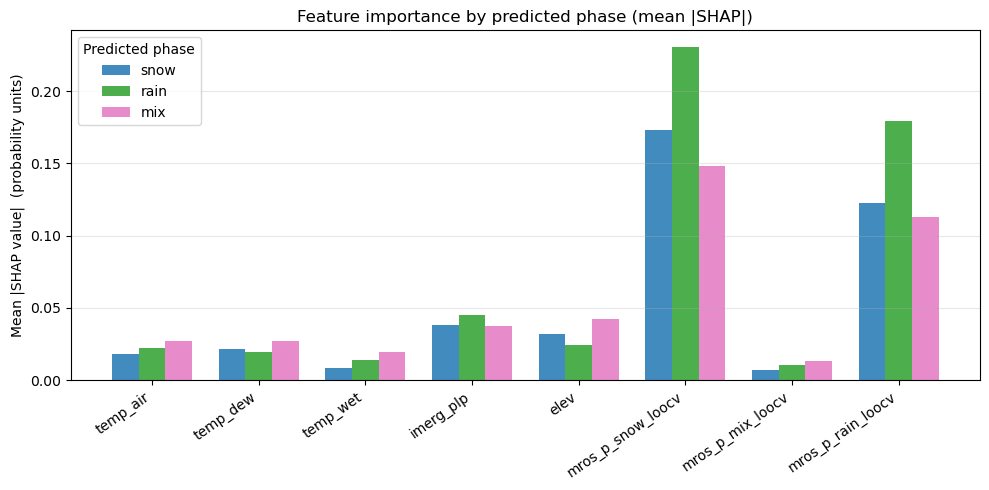

  Saved: shap_mean_by_phase_IDW.png


In [18]:
# =============================================================================
# SHAP ANALYSIS — PER-PHASE FEATURE ATTRIBUTION
# =============================================================================
#
# Computes SHAP values for all observations (train + val + test, full set
# including mix) using TreeExplainer on the fitted XGBoost booster.
#
# SHAP values explain the binary model output (log-odds of snow vs rain).
# Three-phase stratification is achieved by slicing the combined SHAP table
# by the uncertainty-derived phase label (prediction_phase_uncertainty):
#   - snow:  confident prediction above snow threshold
#   - rain:  confident prediction below rain threshold
#   - mix:   observation fell inside the Gaussian uncertainty band
#
# This means "mix SHAP values" are specifically the attributions for
# observations where the model was uncertain — i.e. what features drove
# p(snow) into the ambiguous middle range.
#
# Outputs
# -------
#   shap_values_all.parquet    — one row per obs, one col per feature (SHAP)
#                                plus metadata: time, x, y, phase_full,
#                                prediction_phase_uncertainty, p_snow_cal,
#                                temp_wet, elev, split
#   shap_summary_by_phase.csv  — mean |SHAP| per feature per phase
#   shap_mean_by_phase.png     — beeswarm-style mean |SHAP| bar chart
# =============================================================================

import shap

PHASE_COLORS = {
    "snow": "#1f77b4",   # blue
    "rain": "#2ca02c",   # green
    "mix":  "#e377c2",   # pink
}

# ── Build full combined table (all splits, full phase set) ────────────────────
# Attach split labels so downstream analysis can filter by train/val/test

train_full_shap = train_df_full.copy()
train_full_shap["split"] = "train"

val_full_shap = df_val_full.copy()
val_full_shap["split"] = "val"

test_full_shap = df_test_full.copy()
test_full_shap["split"] = "test"

df_all_full = pd.concat(
    [train_full_shap, val_full_shap, test_full_shap],
    ignore_index=True,
)

# Raw XGBoost probabilities for the full combined set
d_all_full = xgb.DMatrix(df_all_full[FEATURES], feature_names=FEATURES)
p_all_full_raw = booster.predict(d_all_full)

# Calibrated probabilities
p_all_full_cal = apply_regime_calibration(
    p_all_full_raw,
    df_all_full["temp_wet"].to_numpy(),
    final_cal_models,
    CLEAR_PHASE_TWET_C,
)

# Uncertainty-derived phase label for every observation
pred_phase_all = classify_phase_gaussian_band(
    p_all_full_cal,
    df_all_full["temp_wet"].to_numpy(),
    BEST_BASE_HB,
    BEST_EXTRA_HB,
    BEST_SIGMA,
)

# ── Compute SHAP values ───────────────────────────────────────────────────────
print("Computing SHAP values (TreeExplainer, probability output)...")

# tree_path_dependent (the SHAP default) only supports model_output="raw".
# To get SHAP values in probability space we must use feature_perturbation=
# "interventional", which requires a background dataset. We use a stratified
# sample of the training set (500 rows) as the background — large enough to
# be representative, small enough to keep runtime reasonable.

N_BACKGROUND = 500

background = (
    df_all_full[df_all_full["split"] == "train"][FEATURES]
    .groupby(df_all_full[df_all_full["split"] == "train"]["phase_full"], group_keys=False)
    .apply(lambda g: g.sample(
        min(len(g), int(N_BACKGROUND * len(g) / len(df_all_full[df_all_full["split"] == "train"]))),
        random_state=RANDOM_SEED,
    ))
    .reset_index(drop=True)
)
print(f"  Background dataset: {len(background)} rows (stratified sample of train split)")

explainer = shap.TreeExplainer(
    booster,
    data=background,
    feature_perturbation="interventional",
    model_output="probability",
)

shap_values = explainer.shap_values(df_all_full[FEATURES])
print(f"  SHAP array shape: {shap_values.shape}")

# ── Build export table ────────────────────────────────────────────────────────
SHAP_META_COLS = [
    "time", "x", "y", "phase_full",
    "temp_wet", "temp_air", "elev",
]

shap_df = df_all_full[SHAP_META_COLS].copy()
shap_df["split"]                          = df_all_full["split"].values
shap_df["p_snow_cal"]                     = p_all_full_cal
shap_df["prediction_phase_uncertainty"]   = pred_phase_all
shap_df["phase_label"] = shap_df["prediction_phase_uncertainty"].map(
    {SNOW_CODE: "snow", RAIN_CODE: "rain", MIX_CODE: "mix"}
)

for i, feat in enumerate(FEATURES):
    shap_df[f"shap_{feat}"] = shap_values[:, i]

shap_df.to_parquet(MODEL_OUT_DIR / "shap_values_all.parquet")
print(f"  Saved: shap_values_all.parquet  ({len(shap_df)} rows)")

# ── Summary: mean |SHAP| per feature per phase ───────────────────────────────
shap_cols = [f"shap_{f}" for f in FEATURES]

phase_shap_summary = (
    shap_df.groupby("phase_label")[shap_cols]
    .apply(lambda df_: df_.abs().mean())
    .T
    .rename(index=lambda c: c.replace("shap_", ""))
    .rename_axis("feature")
    .reset_index()
)

# Also add an "all" column (mean |SHAP| across all phases)
phase_shap_summary["all"] = (
    pd.DataFrame(np.abs(shap_values), columns=FEATURES).mean(axis=0).values
)

phase_shap_summary = phase_shap_summary.sort_values("all", ascending=False)
phase_shap_summary.to_csv(MODEL_OUT_DIR / "shap_summary_by_phase.csv", index=False)
print("  Saved: shap_summary_by_phase.csv")
print(phase_shap_summary.to_string(index=False))

# ── Plot: mean |SHAP| by phase ────────────────────────────────────────────────
phase_plot_cols = [c for c in ["snow", "rain", "mix"] if c in phase_shap_summary.columns]

x = np.arange(len(FEATURES))
width = 0.25
colors = [PHASE_COLORS["snow"], PHASE_COLORS["rain"], PHASE_COLORS["mix"]]

fig, ax = plt.subplots(figsize=(10, 5))

for i, (phase_col, color) in enumerate(zip(phase_plot_cols, colors)):
    vals = phase_shap_summary.set_index("feature").loc[FEATURES, phase_col].values
    ax.bar(x + i * width, vals, width, label=phase_col, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(FEATURES, rotation=35, ha="right")
ax.set_ylabel("Mean |SHAP value|  (probability units)")
ax.set_title("Feature importance by predicted phase (mean |SHAP|)")
ax.legend(title="Predicted phase")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(GRAPHICS_DIR / f"shap_mean_by_phase_{interp_type}.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"  Saved: shap_mean_by_phase_{interp_type}.png")

In [20]:
# =============================================================================
# METRICS SUMMARY EXPORT
# =============================================================================
#
# Collects all scalar performance metrics computed in the evaluation cell into
# a single metrics_summary.json for easy cross-run comparison.
#
# Structure:
#   binary_probability  — ROC AUC, average precision, Brier, log loss (val+test)
#   binary_hard         — accuracy, balanced accuracy, macro F1, per-class
#                         precision/recall/F1 at 0.5 threshold (val+test)
#   uncertainty_3class  — same hard metrics for uncertainty-derived product (val+test)
#   mix_behavior        — mix capture rate, pure coverage, confident accuracy (val+test)
#   near_freezing       — per-flag, per-split, per-phase recall/precision/F1
#   run_info            — region, interp_type, scale_pos_weight, band params,
#                         class counts, timestamp
# =============================================================================

import datetime
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    log_loss,
    roc_auc_score,
    precision_recall_fscore_support
)


def _binary_prob_metrics(y_true_bin, p_raw, p_cal):
    return {
        "roc_auc_raw":        round(float(roc_auc_score(y_true_bin, p_raw)),  4),
        "roc_auc_cal":        round(float(roc_auc_score(y_true_bin, p_cal)),  4),
        "average_precision":  round(float(average_precision_score(y_true_bin, p_cal)), 4),
        "brier_raw":          round(float(brier_score_loss(y_true_bin, p_raw)), 4),
        "brier_cal":          round(float(brier_score_loss(y_true_bin, p_cal)), 4),
        "log_loss_raw":       round(float(log_loss(y_true_bin, p_raw, labels=[0, 1])), 4),
        "log_loss_cal":       round(float(log_loss(y_true_bin, p_cal, labels=[0, 1])), 4),
    }


def _hard_metrics(y_true, y_pred, phase_codes, phase_names):
    """Scalar + per-class breakdown for any hard-threshold prediction."""
    p, r, f, s = precision_recall_fscore_support(
        y_true, y_pred,
        labels=phase_codes,
        zero_division=0,
    )
    per_class = {
        name: {
            "precision": round(float(p[i]), 4),
            "recall":    round(float(r[i]), 4),
            "f1":        round(float(f[i]), 4),
            "support":   int(s[i]),
        }
        for i, name in enumerate(phase_names)
    }
    return {
        "accuracy":          round(float(accuracy_score(y_true, y_pred)), 4),
        "balanced_accuracy": round(float(balanced_accuracy_score(y_true, y_pred)), 4),
        "macro_f1":          round(float(f1_score(y_true, y_pred,
                                                   average="macro",
                                                   zero_division=0)), 4),
        "per_class":         per_class,
    }


def _mix_behavior_metrics(y_true_phase, y_pred_phase):
    y_true = np.asarray(y_true_phase)
    y_pred = np.asarray(y_pred_phase)

    true_mix  = y_true == MIX_CODE
    true_pure = np.isin(y_true, [SNOW_CODE, RAIN_CODE])
    pred_conf = y_pred != MIX_CODE

    mix_capture      = float(np.mean(y_pred[true_mix]  == MIX_CODE))  if true_mix.any()  else None
    pure_coverage    = float(np.mean(pred_conf[true_pure]))            if true_pure.any() else None
    pure_conf_acc    = float(np.mean(
        y_pred[true_pure & pred_conf] == y_true[true_pure & pred_conf]
    )) if np.any(true_pure & pred_conf) else None
    confident_frac   = float(np.mean(pred_conf))

    return {
        "mix_capture_rate":           round(mix_capture,    4) if mix_capture    is not None else None,
        "pure_phase_confident_coverage": round(pure_coverage, 4) if pure_coverage is not None else None,
        "pure_phase_confident_accuracy": round(pure_conf_acc, 4) if pure_conf_acc is not None else None,
        "overall_confident_frac":     round(confident_frac, 4),
    }


def _near_freezing_metrics(df_full, flag, phase_codes, phase_names):
    sub = df_full[df_full[flag]].copy()
    if sub.empty:
        return {"n_obs": 0}
    p, r, f, s = precision_recall_fscore_support(
        sub["phase_full"],
        sub["prediction_phase_uncertainty"],
        labels=phase_codes,
        zero_division=0,
    )
    return {
        "n_obs":     int(len(sub)),
        "accuracy":  round(float(accuracy_score(
            sub["phase_full"], sub["prediction_phase_uncertainty"])), 4),
        "per_class": {
            name: {
                "precision": round(float(p[i]), 4),
                "recall":    round(float(r[i]), 4),
                "f1":        round(float(f[i]), 4),
                "support":   int(s[i]),
            }
            for i, name in enumerate(phase_names)
        },
    }


# ── Assemble ──────────────────────────────────────────────────────────────────

y_val_bin  = y_val.to_numpy()
y_test_bin = y_test.to_numpy()

metrics_summary = {
    "run_info": {
        "region":             REGION,
        "interp_type":        interp_type,
        "timestamp_utc":      datetime.datetime.utcnow().isoformat(timespec="seconds"),
        "scale_pos_weight":   BEST_SCALE_POS_WEIGHT,
        "gaussian_band": {
            "base_half_band":  BEST_BASE_HB,
            "extra_half_band": BEST_EXTRA_HB,
            "sigma_degC":      BEST_SIGMA,
        },
        "features":           FEATURES,
        "n_train_snow":       int((train_df_fit["phase_full"] == SNOW_CODE).sum()),
        "n_train_rain":       int((train_df_fit["phase_full"] == RAIN_CODE).sum()),
        "n_val_snow":         int((val_df_fit["phase_full"]   == SNOW_CODE).sum()),
        "n_val_rain":         int((val_df_fit["phase_full"]   == RAIN_CODE).sum()),
        "n_test_snow":        int((test_df_fit["phase_full"]  == SNOW_CODE).sum()),
        "n_test_rain":        int((test_df_fit["phase_full"]  == RAIN_CODE).sum()),
    },
    "binary_probability": {
        "val":  _binary_prob_metrics(y_val_bin,  val_fit_prob_raw,  val_fit_prob_cal),
        "test": _binary_prob_metrics(y_test_bin, test_fit_prob_raw, test_fit_prob_cal),
    },
    "binary_hard_05": {
        "val":  _hard_metrics(y_val_fit_phase,  val_fit_pred_binary,
                              [SNOW_CODE, RAIN_CODE], ["snow", "rain"]),
        "test": _hard_metrics(y_test_fit_phase, test_fit_pred_binary,
                              [SNOW_CODE, RAIN_CODE], ["snow", "rain"]),
    },
    "uncertainty_3class": {
        "val":  _hard_metrics(df_val_full["phase_full"],
                              df_val_full["prediction_phase_uncertainty"],
                              [SNOW_CODE, RAIN_CODE, MIX_CODE], FULL_CLASS_NAMES),
        "test": _hard_metrics(df_test_full["phase_full"],
                              df_test_full["prediction_phase_uncertainty"],
                              [SNOW_CODE, RAIN_CODE, MIX_CODE], FULL_CLASS_NAMES),
    },
    "mix_behavior": {
        "val":  _mix_behavior_metrics(df_val_full["phase_full"],
                                      df_val_full["prediction_phase_uncertainty"]),
        "test": _mix_behavior_metrics(df_test_full["phase_full"],
                                      df_test_full["prediction_phase_uncertainty"]),
    },
    "near_freezing": {
        split_name: {
            flag: _near_freezing_metrics(df_full, flag,
                                         [SNOW_CODE, RAIN_CODE, MIX_CODE],
                                         FULL_CLASS_NAMES)
            for flag in ["near_freezing_air_1C", "near_freezing_wet_1C"]
        }
        for split_name, df_full in [("val", df_val_full), ("test", df_test_full)]
    },
}

out_path = MODEL_OUT_DIR / "metrics_summary.json"
with open(out_path, "w") as f:
    json.dump(metrics_summary, f, indent=2)

print(f"Saved: {out_path.name}")
print(f"  Binary test ROC AUC (cal):   {metrics_summary['binary_probability']['test']['roc_auc_cal']}")
print(f"  Binary test rain recall:     {metrics_summary['binary_hard_05']['test']['per_class']['rain']['recall']}")
print(f"  3-class test macro F1:       {metrics_summary['uncertainty_3class']['test']['macro_f1']}")
print(f"  Test mix capture rate:       {metrics_summary['mix_behavior']['test']['mix_capture_rate']}")

Saved: metrics_summary.json
  Binary test ROC AUC (cal):   0.9513
  Binary test rain recall:     0.8827
  3-class test macro F1:       0.6919
  Test mix capture rate:       0.4175


C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_22268\2477057306.py:128: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc":      datetime.datetime.utcnow().isoformat(timespec="seconds"),


In [21]:
# =============================================================================
# VALIDATION / TEST METRICS AND VISUALS
# =============================================================================

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    f1_score,
    log_loss,
    roc_auc_score,
)

PHASE_COLORS = {
    "snow": "#1f77b4",   # blue
    "rain": "#2ca02c",   # green
    "mix":  "#e377c2",   # pink
}


def summarize_binary_probability_metrics(y_true_bin, p_raw, p_cal, name: str) -> None:
    print(f"\n=== {name} | PURE-PHASE BINARY PROBABILITY METRICS ===")
    print(f"ROC AUC (raw/cal):         {roc_auc_score(y_true_bin, p_raw):.4f} / {roc_auc_score(y_true_bin, p_cal):.4f}")
    print(f"Average precision:        {average_precision_score(y_true_bin, p_cal):.4f}")
    print(f"Brier score (raw/cal):    {brier_score_loss(y_true_bin, p_raw):.4f} / {brier_score_loss(y_true_bin, p_cal):.4f}")
    print(f"Log loss (raw/cal):       {log_loss(y_true_bin, p_raw, labels=[0,1]):.4f} / {log_loss(y_true_bin, p_cal, labels=[0,1]):.4f}")


def summarize_binary_hard_metrics(y_true_phase, y_pred_phase, name: str) -> None:
    print(f"\n=== {name} | PURE-PHASE HARD BINARY METRICS (0.5 THRESHOLD) ===")
    print(f"Accuracy:          {accuracy_score(y_true_phase, y_pred_phase):.4f}")
    print(f"Balanced accuracy: {balanced_accuracy_score(y_true_phase, y_pred_phase):.4f}")
    print(f"Macro F1:          {f1_score(y_true_phase, y_pred_phase, average='macro'):.4f}")
    print(classification_report(
        y_true_phase,
        y_pred_phase,
        labels=[SNOW_CODE, RAIN_CODE],
        target_names=["snow", "rain"],
        digits=4,
        zero_division=0,
    ))


def summarize_uncertainty_phase_metrics(y_true_phase, y_pred_phase, name: str) -> None:
    print(f"\n=== {name} | UNCERTAINTY-DERIVED 3-CLASS METRICS ===")
    print(f"Accuracy:          {accuracy_score(y_true_phase, y_pred_phase):.4f}")
    print(f"Balanced accuracy: {balanced_accuracy_score(y_true_phase, y_pred_phase):.4f}")
    print(f"Macro F1:          {f1_score(y_true_phase, y_pred_phase, average='macro'):.4f}")
    print(classification_report(
        y_true_phase,
        y_pred_phase,
        labels=[SNOW_CODE, RAIN_CODE, MIX_CODE],
        target_names=FULL_CLASS_NAMES,
        digits=4,
        zero_division=0,
    ))


def summarize_mix_uncertainty_behavior(y_true_phase, y_pred_phase, dataset_name: str) -> None:
    y_true_phase = np.asarray(y_true_phase)
    y_pred_phase = np.asarray(y_pred_phase)

    true_mix = y_true_phase == MIX_CODE
    true_pure = np.isin(y_true_phase, [SNOW_CODE, RAIN_CODE])
    pred_mix = y_pred_phase == MIX_CODE
    pred_conf = y_pred_phase != MIX_CODE

    mix_capture = pred_mix[true_mix].mean() if true_mix.any() else np.nan
    pure_coverage = pred_conf[true_pure].mean() if true_pure.any() else np.nan
    pure_conf_acc = (y_pred_phase[true_pure & pred_conf] == y_true_phase[true_pure & pred_conf]).mean() if np.any(true_pure & pred_conf) else np.nan
    confident_fraction_all = pred_conf.mean()

    print(f"\n=== {dataset_name} | MIX / UNCERTAINTY BEHAVIOR ===")
    print(f"True-mix capture rate:            {mix_capture:.4f}")
    print(f"Pure-phase confident coverage:    {pure_coverage:.4f}")
    print(f"Pure-phase confident accuracy:    {pure_conf_acc:.4f}")
    print(f"Overall confident prediction frac:{confident_fraction_all:.4f}")


# ---------------------------------------------------------------------
# Validation diagnostics (probabilities + uncertainty product)
# ---------------------------------------------------------------------
y_val_bin = y_val.to_numpy()
y_test_bin = y_test.to_numpy()

summarize_binary_probability_metrics(y_val_bin, val_fit_prob_raw, val_fit_prob_cal, "Validation")
summarize_binary_probability_metrics(y_test_bin, test_fit_prob_raw, test_fit_prob_cal, "Test")

summarize_binary_hard_metrics(y_val_fit_phase, val_fit_pred_binary, "Validation")
summarize_binary_hard_metrics(y_test_fit_phase, test_fit_pred_binary, "Test")

summarize_uncertainty_phase_metrics(
    df_val_full["phase_full"],
    df_val_full["prediction_phase_uncertainty"],
    "Validation",
)
summarize_uncertainty_phase_metrics(
    df_test_full["phase_full"],
    df_test_full["prediction_phase_uncertainty"],
    "Test",
)
summarize_mix_uncertainty_behavior(
    df_val_full["phase_full"],
    df_val_full["prediction_phase_uncertainty"],
    "Validation",
)
summarize_mix_uncertainty_behavior(
    df_test_full["phase_full"],
    df_test_full["prediction_phase_uncertainty"],
    "Test",
)

# ---------------------------------------------------------------------
# Near-freezing subset summaries for the full uncertainty-derived product
# ---------------------------------------------------------------------
for name, df_ in [("Validation", df_val_full), ("Test", df_test_full)]:
    for flag in ["near_freezing_air_1C", "near_freezing_wet_1C"]:
        sub = df_[df_[flag]].copy()
        if sub.empty:
            continue
        print(f"\n=== {name} | {flag} | uncertainty-derived 3-class report ===")
        print(classification_report(
            sub["phase_full"],
            sub["prediction_phase_uncertainty"],
            labels=[SNOW_CODE, RAIN_CODE, MIX_CODE],
            target_names=FULL_CLASS_NAMES,
            digits=4,
            zero_division=0,
        ))



=== Validation | PURE-PHASE BINARY PROBABILITY METRICS ===
ROC AUC (raw/cal):         0.9776 / 0.9802
Average precision:        0.9884
Brier score (raw/cal):    0.0597 / 0.0546
Log loss (raw/cal):       0.1971 / 0.1737

=== Test | PURE-PHASE BINARY PROBABILITY METRICS ===
ROC AUC (raw/cal):         0.9596 / 0.9513
Average precision:        0.9643
Brier score (raw/cal):    0.0696 / 0.0710
Log loss (raw/cal):       0.2463 / 0.8140

=== Validation | PURE-PHASE HARD BINARY METRICS (0.5 THRESHOLD) ===
Accuracy:          0.9201
Balanced accuracy: 0.9184
Macro F1:          0.9129
              precision    recall  f1-score   support

        snow     0.9524    0.9239    0.9379       368
        rain     0.8641    0.9128    0.8878       195

    accuracy                         0.9201       563
   macro avg     0.9082    0.9184    0.9129       563
weighted avg     0.9218    0.9201    0.9206       563


=== Test | PURE-PHASE HARD BINARY METRICS (0.5 THRESHOLD) ===
Accuracy:          0.9113
Bal

Loaded val_fit:   (563, 37)
Loaded test_fit:  (564, 37)
Loaded val_full:  (666, 36)
Loaded test_full: (667, 36)


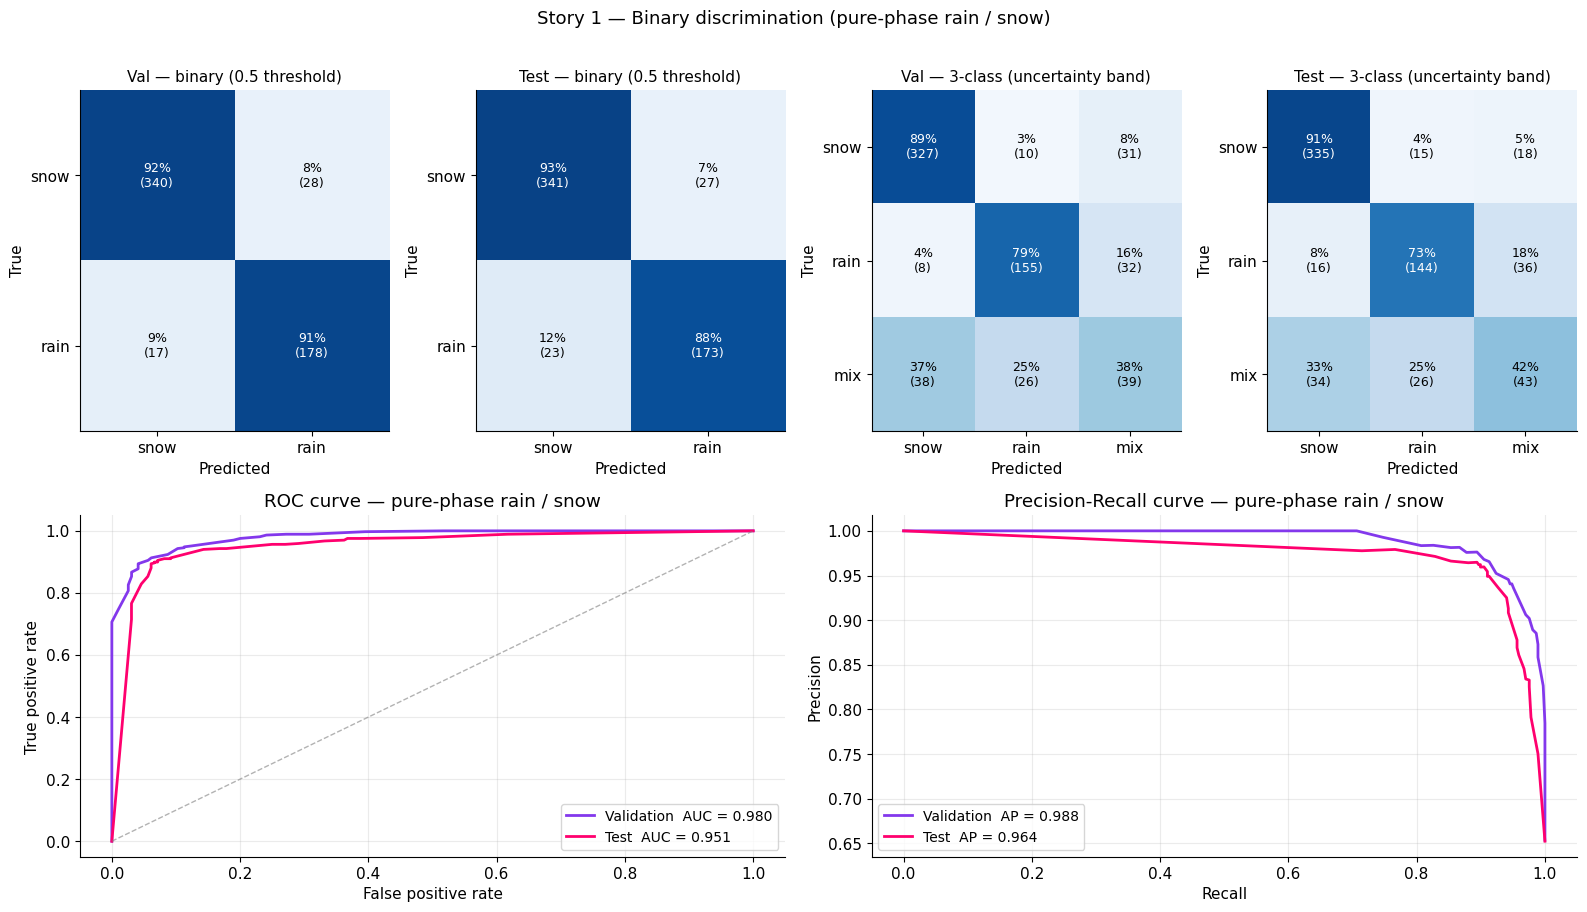


  VALIDATION | pure-phase binary summary
  ROC AUC            : 0.9802
  Average precision  : 0.9884
  Brier score (cal)  : 0.0546
  Balanced accuracy  : 0.9184
  Macro F1           : 0.9129
              precision    recall  f1-score   support

        snow      0.952     0.924     0.938       368
        rain      0.864     0.913     0.888       195

    accuracy                          0.920       563
   macro avg      0.908     0.918     0.913       563
weighted avg      0.922     0.920     0.921       563


  TEST | pure-phase binary summary
  ROC AUC            : 0.9513
  Average precision  : 0.9643
  Brier score (cal)  : 0.0710
  Balanced accuracy  : 0.9046
  Macro F1           : 0.9027
              precision    recall  f1-score   support

        snow      0.937     0.927     0.932       368
        rain      0.865     0.883     0.874       196

    accuracy                          0.911       564
   macro avg      0.901     0.905     0.903       564
weighted avg      0.912

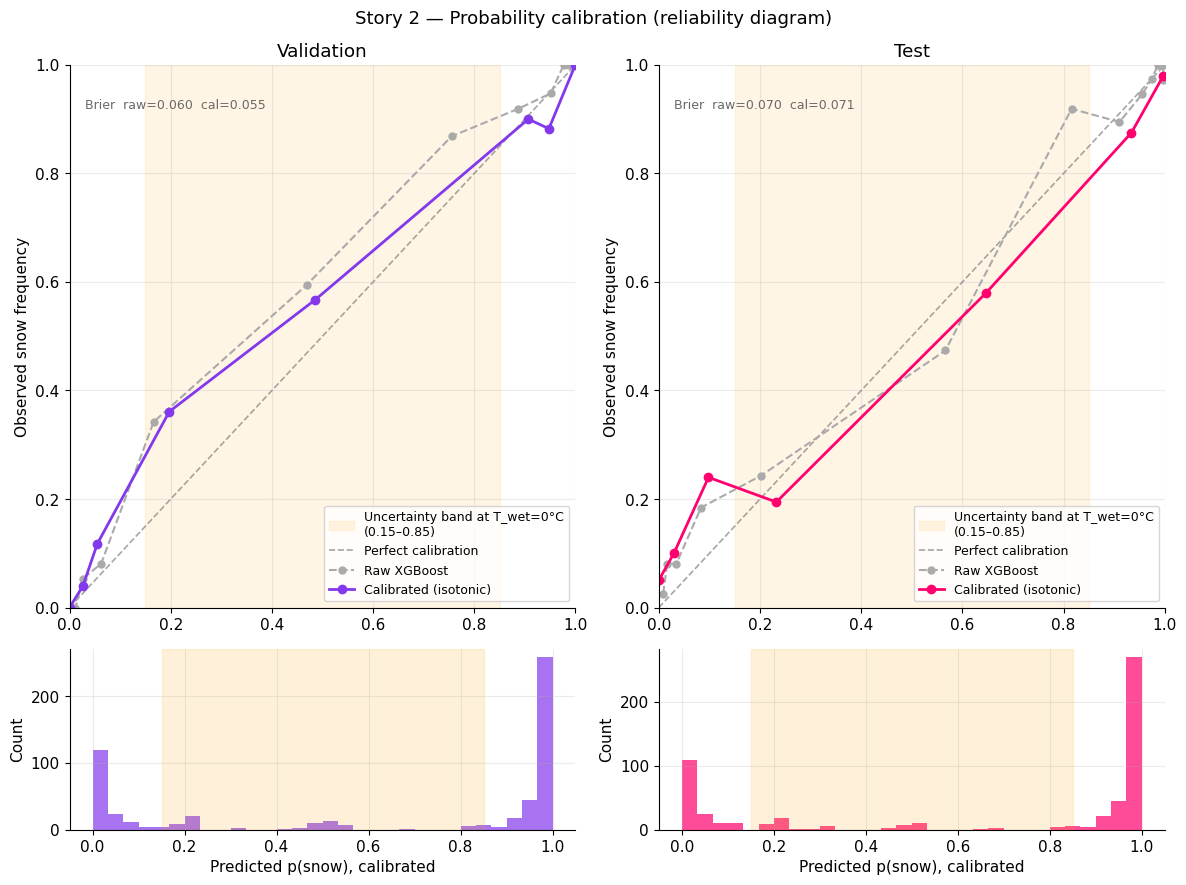

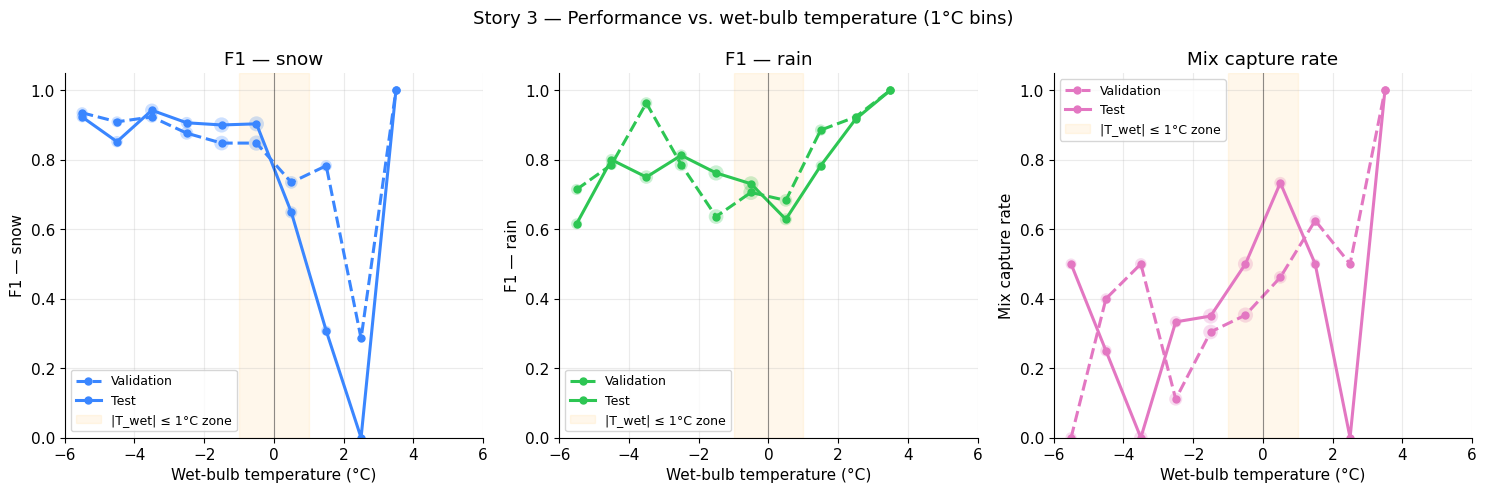

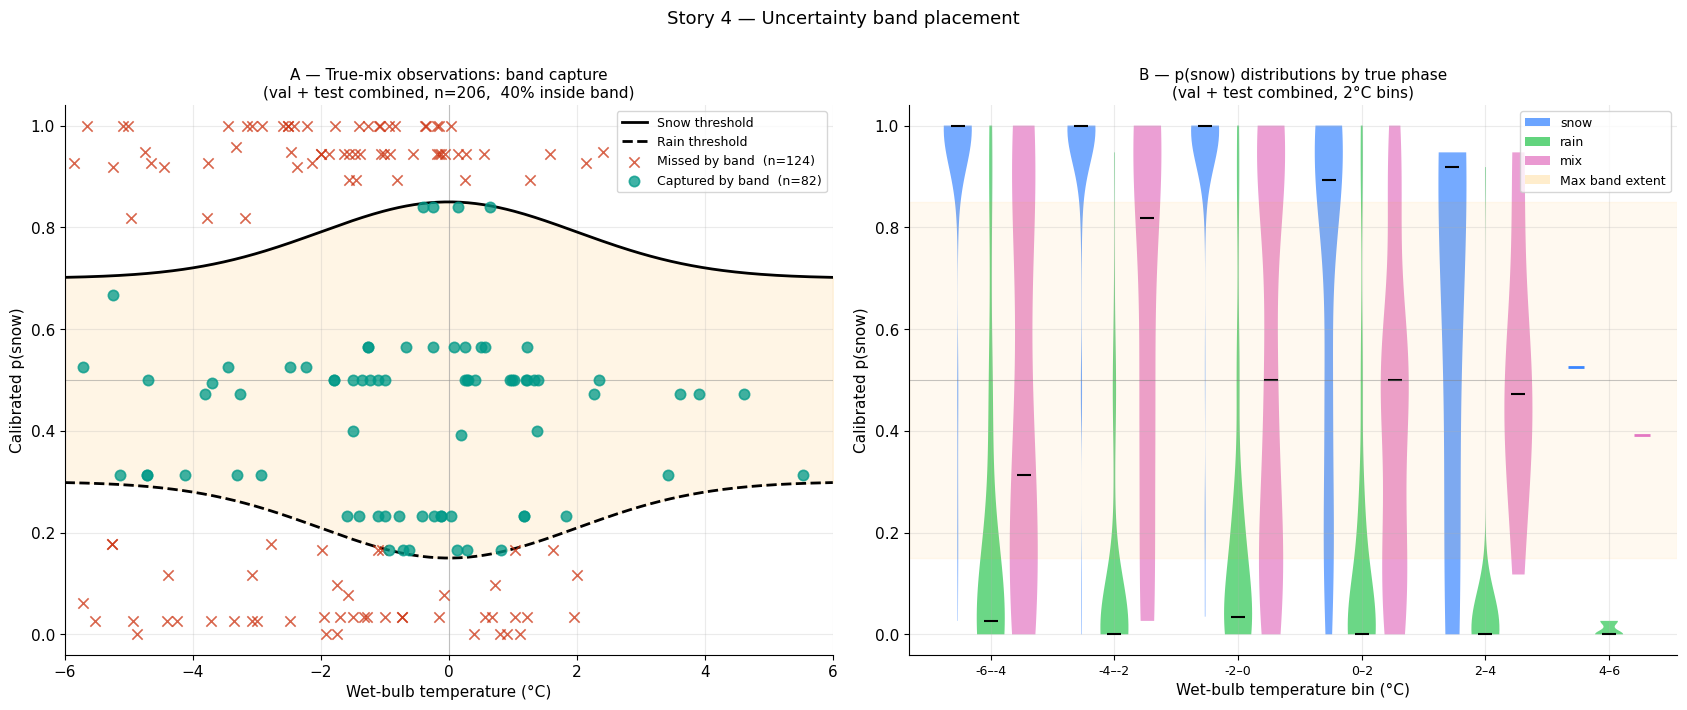


Story 4 — Mix band capture summary (val + test combined)
  True-mix observations : 206
  Inside band           : 82  (39.8%)
  Outside band          : 124  (60.2%)

  VALIDATION | |T_air| ≤ 1°C
              precision    recall  f1-score   support

        snow      0.960     0.935     0.947        77
        rain      0.500     0.750     0.600         8
         mix      0.167     0.125     0.143         8

    accuracy                          0.849        93
   macro avg      0.542     0.603     0.563        93
weighted avg      0.852     0.849     0.848        93


  VALIDATION | |T_wet| ≤ 1°C
              precision    recall  f1-score   support

        snow      0.814     0.803     0.809        71
        rain      0.821     0.604     0.696        53
         mix      0.267     0.400     0.320        30

    accuracy                          0.656       154
   macro avg      0.634     0.602     0.608       154
weighted avg      0.710     0.656     0.675       154


  TEST | |T_

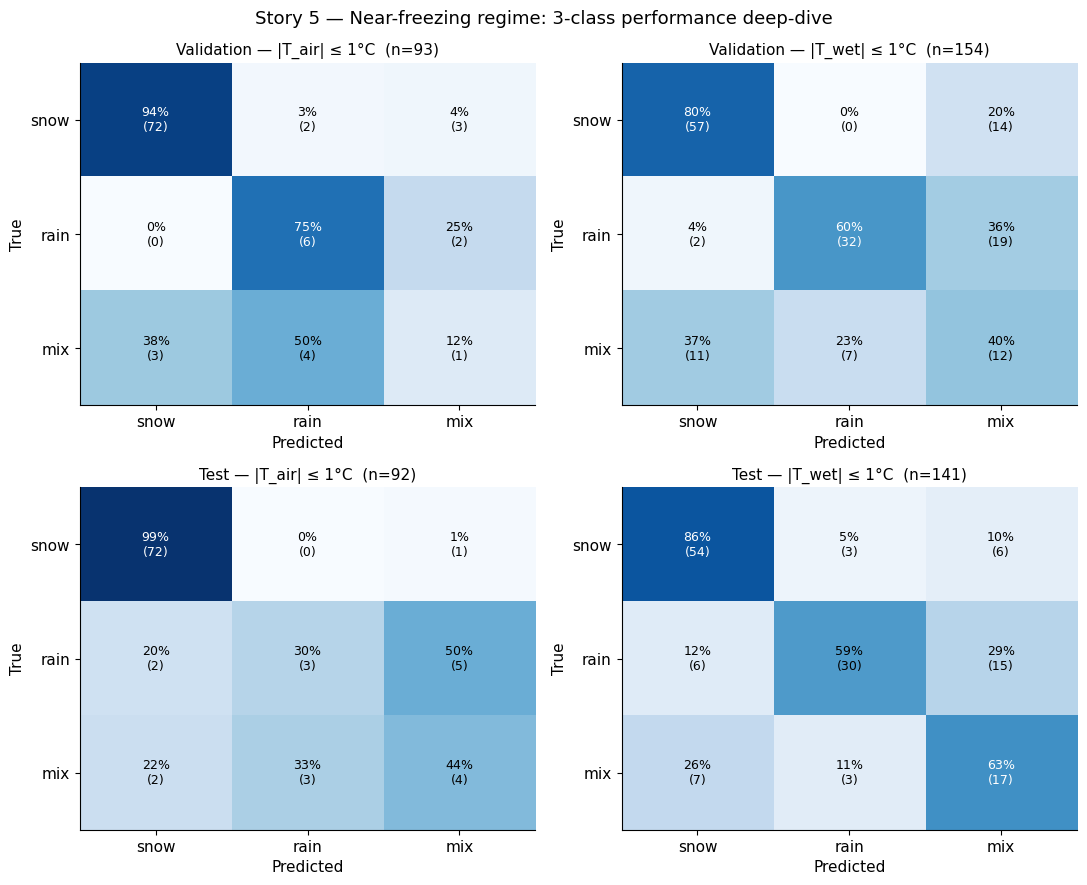


  VALIDATION | Mix / uncertainty behavior
  True-mix capture rate          : 0.379
  Pure-phase confident coverage  : 0.888
  Pure-phase confident accuracy  : 0.964
  Overall confident fraction     : 0.847

  TEST | Mix / uncertainty behavior
  True-mix capture rate          : 0.417
  Pure-phase confident coverage  : 0.904
  Pure-phase confident accuracy  : 0.939
  Overall confident fraction     : 0.855


All plots saved to: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\ML_pipeline\model_artifacts\CA\results_binaryXGB_withIDW\graphics


In [22]:
# =============================================================================
# VALIDATION / TEST METRICS AND VISUALS Contd.
# =============================================================================
#
# This cell is self-contained: it loads all required arrays and dataframes
# directly from the saved parquet files in MODEL_OUT_DIR, so it can be re-run
# without executing any earlier modelling cells.
#
# Visual narrative
# ----------------
#   Story 1 — Binary discrimination      : normalized confusion matrices + ROC/PR
#   Story 2 — Probability calibration    : reliability diagram with band overlay
#   Story 3 — Performance vs. temperature: F1 / recall curves over T_wet bins
#   Story 4 — Uncertainty band placement : T_wet × p(snow) density + band curves
#   Story 5 — Near-freezing deep-dive    : normalized 3-class confusion matrices
#             at |T_air| ≤ 1°C and |T_wet| ≤ 1°C
#
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

# ── Style constants ────────────────────────────────────────────────────────────
PHASE_COLORS = {"snow": "#3a86ff", "rain": "#2dc653", "mix": "#e377c2"}
SPLIT_COLORS = {"Validation": "#8338ec", "Test": "#ff006e"}

SNOW_CODE = 0
RAIN_CODE = 1
MIX_CODE  = 2
FULL_CLASS_NAMES = ["snow", "rain", "mix"]
BINARY_LABEL_MAP = {RAIN_CODE: 0, SNOW_CODE: 1}   # 0 = rain, 1 = snow

BAND_BASE  = 0.20   # base_half_band used in Gaussian derivation
BAND_EXTRA = 0.15   # extra_half_band
BAND_SIGMA = 2.0    # sigma (°C)

plt.rcParams.update({
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.25,
    "font.size":          11,
})


# =============================================================================
# LOAD SAVED OUTPUTS
# =============================================================================
# All arrays are reconstructed from the parquet files saved by the export cell.
# No model objects or earlier-cell variables are required.

df_val_fit   = pd.read_parquet(MODEL_OUT_DIR / "val_fit_binary_predictions_combined.parquet")
df_test_fit  = pd.read_parquet(MODEL_OUT_DIR / "test_fit_binary_predictions_combined.parquet")
df_val_full  = pd.read_parquet(MODEL_OUT_DIR / "val_full_uncertainty_predictions_combined.parquet")
df_test_full = pd.read_parquet(MODEL_OUT_DIR / "test_full_uncertainty_predictions_combined.parquet")

# Reconstruct numpy arrays used by sklearn metrics
y_val_bin          = df_val_fit["phase_binary"].to_numpy()
y_test_bin         = df_test_fit["phase_binary"].to_numpy()

val_fit_prob_raw   = df_val_fit["p_snow_raw"].to_numpy()
val_fit_prob_cal   = df_val_fit["p_snow_cal"].to_numpy()
test_fit_prob_raw  = df_test_fit["p_snow_raw"].to_numpy()
test_fit_prob_cal  = df_test_fit["p_snow_cal"].to_numpy()

val_fit_pred_binary   = df_val_fit["prediction_binary05"].to_numpy()
test_fit_pred_binary  = df_test_fit["prediction_binary05"].to_numpy()

y_val_fit_phase   = df_val_fit["phase_full"].to_numpy()
y_test_fit_phase  = df_test_fit["phase_full"].to_numpy()

print("Loaded val_fit:  ", df_val_fit.shape)
print("Loaded test_fit: ", df_test_fit.shape)
print("Loaded val_full: ", df_val_full.shape)
print("Loaded test_full:", df_test_full.shape)


# =============================================================================
# HELPER: Gaussian half-band
# =============================================================================

def gaussian_half_band(t_wet: np.ndarray,
                       base: float = BAND_BASE,
                       extra: float = BAND_EXTRA,
                       sigma: float = BAND_SIGMA) -> np.ndarray:
    return base + extra * np.exp(-(t_wet ** 2) / (2 * sigma ** 2))


# =============================================================================
# STORY 1 — Binary discrimination
# =============================================================================
# Normalized confusion matrices (row-normalized → % of true class) for the
# pure-phase binary classifier, plus combined ROC and PR curves.
# ---------------------------------------------------------------------------

def plot_normalized_cm(ax, y_true, y_pred, labels, display_labels, title, cmap="Blues"):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    n = len(labels)
    im = ax.imshow(cm_norm, vmin=0, vmax=1, cmap=cmap, aspect="auto")
    ax.set_xticks(range(n)); ax.set_xticklabels(display_labels)
    ax.set_yticks(range(n)); ax.set_yticklabels(display_labels)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title, fontsize=11)
    ax.grid(False)
    for i in range(n):
        for j in range(n):
            color = "white" if cm_norm[i, j] > 0.6 else "black"
            ax.text(j, i, f"{cm_norm[i,j]:.0%}\n({cm[i,j]})",
                    ha="center", va="center", fontsize=9, color=color)
    return im


fig = plt.figure(figsize=(16, 9))
fig.suptitle("Story 1 — Binary discrimination (pure-phase rain / snow)", fontsize=13, y=1.01)

# ── Row 1: normalized confusion matrices ──────────────────────────────────────
ax00 = fig.add_subplot(2, 4, 1)
ax01 = fig.add_subplot(2, 4, 2)
ax02 = fig.add_subplot(2, 4, 3)
ax03 = fig.add_subplot(2, 4, 4)

plot_normalized_cm(ax00, y_val_fit_phase,  val_fit_pred_binary,
                   [SNOW_CODE, RAIN_CODE], ["snow", "rain"],
                   "Val — binary (0.5 threshold)")
plot_normalized_cm(ax01, y_test_fit_phase, test_fit_pred_binary,
                   [SNOW_CODE, RAIN_CODE], ["snow", "rain"],
                   "Test — binary (0.5 threshold)")
plot_normalized_cm(ax02, df_val_full["phase_full"],
                   df_val_full["prediction_phase_uncertainty"],
                   [SNOW_CODE, RAIN_CODE, MIX_CODE], FULL_CLASS_NAMES,
                   "Val — 3-class (uncertainty band)")
plot_normalized_cm(ax03, df_test_full["phase_full"],
                   df_test_full["prediction_phase_uncertainty"],
                   [SNOW_CODE, RAIN_CODE, MIX_CODE], FULL_CLASS_NAMES,
                   "Test — 3-class (uncertainty band)")

# ── Row 2: ROC + PR curves ────────────────────────────────────────────────────
ax_roc = fig.add_subplot(2, 4, (5, 6))
ax_pr  = fig.add_subplot(2, 4, (7, 8))

for y_true_b, p_cal, split in [
    (y_val_bin,  val_fit_prob_cal,  "Validation"),
    (y_test_bin, test_fit_prob_cal, "Test"),
]:
    color = SPLIT_COLORS[split]
    fpr, tpr, _ = roc_curve(y_true_b, p_cal)
    prec, rec, _ = precision_recall_curve(y_true_b, p_cal)
    auc  = roc_auc_score(y_true_b, p_cal)
    ap   = average_precision_score(y_true_b, p_cal)
    ax_roc.plot(fpr, tpr, color=color, lw=2,
                label=f"{split}  AUC = {auc:.3f}")
    ax_pr.plot(rec, prec, color=color, lw=2,
               label=f"{split}  AP = {ap:.3f}")

ax_roc.plot([0, 1], [0, 1], "--", color="grey", lw=1, alpha=0.6)
ax_roc.set_xlabel("False positive rate"); ax_roc.set_ylabel("True positive rate")
ax_roc.set_title("ROC curve — pure-phase rain / snow")
ax_roc.legend(fontsize=10)

ax_pr.set_xlabel("Recall"); ax_pr.set_ylabel("Precision")
ax_pr.set_title("Precision-Recall curve — pure-phase rain / snow")
ax_pr.legend(fontsize=10)

plt.tight_layout()
plt.savefig(GRAPHICS_DIR / f"story1_discrimination_{interp_type}.png",
            dpi=180, bbox_inches="tight")
plt.show()

# ── Scalar summary ─────────────────────────────────────────────────────────────
for y_true_b, p_raw, p_cal, y_pred, y_true_ph, split in [
    (y_val_bin,  val_fit_prob_raw,  val_fit_prob_cal,
     val_fit_pred_binary,  y_val_fit_phase,  "Validation"),
    (y_test_bin, test_fit_prob_raw, test_fit_prob_cal,
     test_fit_pred_binary, y_test_fit_phase, "Test"),
]:
    print(f"\n{'='*60}")
    print(f"  {split.upper()} | pure-phase binary summary")
    print(f"{'='*60}")
    print(f"  ROC AUC            : {roc_auc_score(y_true_b, p_cal):.4f}")
    print(f"  Average precision  : {average_precision_score(y_true_b, p_cal):.4f}")
    print(f"  Brier score (cal)  : {brier_score_loss(y_true_b, p_cal):.4f}")
    print(f"  Balanced accuracy  : {balanced_accuracy_score(y_true_ph, y_pred):.4f}")
    print(f"  Macro F1           : {f1_score(y_true_ph, y_pred, average='macro'):.4f}")
    print(classification_report(y_true_ph, y_pred,
                                labels=[SNOW_CODE, RAIN_CODE],
                                target_names=["snow", "rain"],
                                digits=3, zero_division=0))


# =============================================================================
# STORY 2 — Probability calibration
# =============================================================================
# Reliability diagram: observed snow frequency vs. mean predicted p(snow).
# Histogram of prediction counts shown below.
# Shaded band marks the Gaussian uncertainty zone (evaluated at T_wet = 0).
# ---------------------------------------------------------------------------

band_at_zero = gaussian_half_band(np.array([0.0]))[0]
rain_thresh_0 = 0.5 - band_at_zero
snow_thresh_0 = 0.5 + band_at_zero

fig, axes = plt.subplots(2, 2, figsize=(12, 9),
                         gridspec_kw={"height_ratios": [3, 1]})
fig.suptitle("Story 2 — Probability calibration (reliability diagram)", fontsize=13)

for col, (y_true_b, p_raw, p_cal, split) in enumerate([
    (y_val_bin,  val_fit_prob_raw,  val_fit_prob_cal,  "Validation"),
    (y_test_bin, test_fit_prob_raw, test_fit_prob_cal, "Test"),
]):
    ax_rel  = axes[0, col]
    ax_hist = axes[1, col]

    frac_raw, mean_raw = calibration_curve(y_true_b, p_raw, n_bins=15, strategy="quantile")
    frac_cal, mean_cal = calibration_curve(y_true_b, p_cal, n_bins=15, strategy="quantile")

    # Uncertainty band shading
    ax_rel.axvspan(rain_thresh_0, snow_thresh_0, alpha=0.10, color="orange",
                   label=f"Uncertainty band at T_wet=0°C\n({rain_thresh_0:.2f}–{snow_thresh_0:.2f})")
    ax_rel.plot([0, 1], [0, 1], "--", color="grey", lw=1.2, alpha=0.7, label="Perfect calibration")
    ax_rel.plot(mean_raw, frac_raw, "o--", color="#aaaaaa", lw=1.5, ms=5, label="Raw XGBoost")
    ax_rel.plot(mean_cal, frac_cal, "o-",  color=SPLIT_COLORS[split], lw=2,  ms=6, label="Calibrated (isotonic)")
    ax_rel.set_xlim(0, 1); ax_rel.set_ylim(0, 1)
    ax_rel.set_ylabel("Observed snow frequency")
    ax_rel.set_title(f"{split}")
    ax_rel.legend(fontsize=9)

    bs_raw = brier_score_loss(y_true_b, p_raw)
    bs_cal = brier_score_loss(y_true_b, p_cal)
    ax_rel.text(0.03, 0.92,
                f"Brier  raw={bs_raw:.3f}  cal={bs_cal:.3f}",
                transform=ax_rel.transAxes, fontsize=9, color="dimgrey")

    # Histogram of p(snow) values
    ax_hist.hist(p_cal, bins=30, color=SPLIT_COLORS[split], alpha=0.7, edgecolor="none")
    ax_hist.axvspan(rain_thresh_0, snow_thresh_0, alpha=0.15, color="orange")
    ax_hist.set_xlabel("Predicted p(snow), calibrated")
    ax_hist.set_ylabel("Count")
    ax_hist.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))

axes[0, 0].set_xlabel("")
axes[0, 1].set_xlabel("")
plt.tight_layout()
plt.savefig(GRAPHICS_DIR / f"story2_calibration_{interp_type}.png",
            dpi=180, bbox_inches="tight")
plt.show()


# =============================================================================
# STORY 3 — Performance vs. wet-bulb temperature
# =============================================================================
# F1 score (snow, rain) and mix capture rate binned by T_wet in 1°C intervals.
# Separate lines for validation and test. Shows where performance degrades
# and how sharply it does so near the phase transition.
# ---------------------------------------------------------------------------

def twet_performance_profile(df_full, bin_edges, snow_code, rain_code, mix_code):
    """Return a DataFrame with per-bin metrics for the full (3-class) product."""
    records = []
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (df_full["temp_wet"] >= lo) & (df_full["temp_wet"] < hi)
        sub = df_full[mask]
        if len(sub) < 10:
            continue
        y_true = sub["phase_full"].to_numpy()
        y_pred = sub["prediction_phase_uncertainty"].to_numpy()

        def f1_for(code):
            tp = np.sum((y_true == code) & (y_pred == code))
            fp = np.sum((y_true != code) & (y_pred == code))
            fn = np.sum((y_true == code) & (y_pred != code))
            p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

        true_mix = y_true == mix_code
        pred_mix = y_pred == mix_code
        mix_cap  = pred_mix[true_mix].mean() if true_mix.any() else np.nan

        records.append({
            "t_mid":        (lo + hi) / 2,
            "n":            len(sub),
            "f1_snow":      f1_for(snow_code),
            "f1_rain":      f1_for(rain_code),
            "mix_capture":  mix_cap,
            "accuracy":     accuracy_score(y_true, y_pred),
        })
    return pd.DataFrame(records)


bin_edges = np.arange(-6, 7, 1)   # 1°C bins from −6 to +6

prof_val  = twet_performance_profile(df_val_full,  bin_edges, SNOW_CODE, RAIN_CODE, MIX_CODE)
prof_test = twet_performance_profile(df_test_full, bin_edges, SNOW_CODE, RAIN_CODE, MIX_CODE)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
fig.suptitle("Story 3 — Performance vs. wet-bulb temperature (1°C bins)", fontsize=13)

metrics = [
    ("f1_snow",     "F1 — snow",      PHASE_COLORS["snow"]),
    ("f1_rain",     "F1 — rain",      PHASE_COLORS["rain"]),
    ("mix_capture", "Mix capture rate", PHASE_COLORS["mix"]),
]

for ax, (col, ylabel, color) in zip(axes, metrics):
    for prof, split, ls in [(prof_val, "Validation", "--"), (prof_test, "Test", "-")]:
        ax.plot(prof["t_mid"], prof[col], ls, color=color, lw=2.2,
                label=split, marker="o", ms=5)
        # bubble size = N
        ax.scatter(prof["t_mid"], prof[col],
                   s=prof["n"] / prof["n"].max() * 120,
                   color=color, alpha=0.25, edgecolors="none")

    ax.axvspan(-1, 1, alpha=0.08, color="orange", label="|T_wet| ≤ 1°C zone")
    ax.axvline(0, color="black", lw=0.8, alpha=0.4)
    ax.set_xlabel("Wet-bulb temperature (°C)")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.set_xlim(bin_edges[0], bin_edges[-1])
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(GRAPHICS_DIR / f"story3_twet_performance_{interp_type}.png",
            dpi=180, bbox_inches="tight")
plt.show()


# =============================================================================
# STORY 4 — Uncertainty band placement  (redesigned)
# =============================================================================
#
# Two panels tell complementary stories:
#
#   Panel A — Mix band capture scatter (val + test combined)
#     Only true-mix observations are plotted as individual points at their
#     actual (T_wet, p_snow_cal) position. Points are coloured by whether
#     the band captured them (inside) or missed them (outside). Band curves
#     are drawn over the top. This directly answers "is the band in the
#     right place for the events that matter most?"
#
#   Panel B — p(snow) distribution by true phase across T_wet bins (violins)
#     The full dataset is binned into 2°C T_wet intervals. Within each bin,
#     violin plots show the p(snow) distribution for snow, rain, and mix
#     observations separately. This shows how well-separated the three phases
#     are in probability space as temperature changes, and where the model
#     starts to lose discrimination.
#
# ---------------------------------------------------------------------------
 
t_wet_grid = np.linspace(-6, 6, 300)
hb         = gaussian_half_band(t_wet_grid)
snow_boundary = 0.5 + hb
rain_boundary = 0.5 - hb
 
# ── Combine val + test for Panel A (more mix observations = better picture) ──
df_mix_all = pd.concat([
    df_val_full[df_val_full["phase_full"] == MIX_CODE].assign(split="Validation"),
    df_test_full[df_test_full["phase_full"] == MIX_CODE].assign(split="Test"),
], ignore_index=True)
 
# Determine whether each mix observation falls inside the band
hb_per_obs = gaussian_half_band(df_mix_all["temp_wet"].to_numpy())
inside_band = (
    (df_mix_all["p_snow_cal"].to_numpy() > 0.5 - hb_per_obs) &
    (df_mix_all["p_snow_cal"].to_numpy() < 0.5 + hb_per_obs)
)
df_mix_all["inside_band"] = inside_band
 
n_inside  = inside_band.sum()
n_total_m = len(inside_band)
capture_pct = 100 * n_inside / n_total_m if n_total_m > 0 else 0
 
# ── Panel B bins ─────────────────────────────────────────────────────────────
VIOLIN_BINS   = [(-6, -4), (-4, -2), (-2, 0), (0, 2), (2, 4), (4, 6)]
bin_labels    = [f"{lo}–{hi}" for lo, hi in VIOLIN_BINS]
df_full_combo = pd.concat([df_val_full, df_test_full], ignore_index=True)
 
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle("Story 4 — Uncertainty band placement", fontsize=13, y=1.01)
 
# ─────────────────────────────────────────────────────────────────────────────
# Panel A: mix observation scatter coloured by band capture
# ─────────────────────────────────────────────────────────────────────────────
ax_a = axes[0]
 
# Band fill and curves
ax_a.fill_between(t_wet_grid, rain_boundary, snow_boundary,
                  alpha=0.10, color="orange", zorder=1)
ax_a.plot(t_wet_grid, snow_boundary, color="black", lw=2.0, ls="-",  zorder=2,
          label="Snow threshold")
ax_a.plot(t_wet_grid, rain_boundary, color="black", lw=2.0, ls="--", zorder=2,
          label="Rain threshold")
 
# Scatter: missed mix (outside band) drawn first so captured points sit on top
for flag, label, color, marker, zorder in [
    (False, "Missed by band",    "#cc3311", "x", 3),
    (True,  "Captured by band",  "#009988", "o", 4),
]:
    sub = df_mix_all[df_mix_all["inside_band"] == flag]
    ax_a.scatter(
        sub["temp_wet"], sub["p_snow_cal"],
        c=color, marker=marker, s=55, alpha=0.75,
        linewidths=1.2, label=f"{label}  (n={len(sub)})",
        zorder=zorder,
    )
 
ax_a.axvline(0,   color="grey", lw=0.8, alpha=0.45, zorder=1)
ax_a.axhline(0.5, color="grey", lw=0.8, alpha=0.45, zorder=1)
ax_a.set_xlim(-6, 6)
ax_a.set_ylim(-0.04, 1.04)
ax_a.set_xlabel("Wet-bulb temperature (°C)", fontsize=11)
ax_a.set_ylabel("Calibrated p(snow)", fontsize=11)
ax_a.set_title(
    f"A — True-mix observations: band capture\n"
    f"(val + test combined, n={n_total_m},  {capture_pct:.0f}% inside band)",
    fontsize=11,
)
ax_a.legend(fontsize=9, loc="upper right")
 
# ─────────────────────────────────────────────────────────────────────────────
# Panel B: p(snow) violin by phase across 2°C T_wet bins
# ─────────────────────────────────────────────────────────────────────────────
ax_b = axes[1]
 
# Build a list of (bin_label, phase_name, array_of_p_snow) tuples
violin_data = {}   # key: (bin_idx, phase_name)  value: np.array
for b_idx, (lo, hi) in enumerate(VIOLIN_BINS):
    mask_bin = (df_full_combo["temp_wet"] >= lo) & (df_full_combo["temp_wet"] < hi)
    sub_bin  = df_full_combo[mask_bin]
    for code, cname in zip([SNOW_CODE, RAIN_CODE, MIX_CODE], FULL_CLASS_NAMES):
        vals = sub_bin.loc[sub_bin["phase_full"] == code, "p_snow_cal"].to_numpy()
        violin_data[(b_idx, cname)] = vals
 
n_bins   = len(VIOLIN_BINS)
n_phases = 3
group_w  = 0.8          # total width allocated per T_wet bin
phase_w  = group_w / n_phases
 
x_ticks = []
x_labels = []
 
for b_idx in range(n_bins):
    bin_center = b_idx  # integer spacing
    x_ticks.append(bin_center)
    x_labels.append(bin_labels[b_idx])
 
    for p_idx, (code, cname) in enumerate(
        zip([SNOW_CODE, RAIN_CODE, MIX_CODE], FULL_CLASS_NAMES)
    ):
        vals = violin_data[(b_idx, cname)]
        x_pos = bin_center + (p_idx - 1) * phase_w   # offset within bin
 
        if len(vals) < 4:
            # Too few points — plot a horizontal tick instead
            ax_b.plot(x_pos, np.median(vals) if len(vals) > 0 else 0.5,
                      "_", color=PHASE_COLORS[cname], ms=12, mew=2)
            continue
 
        parts = ax_b.violinplot(
            vals, positions=[x_pos], widths=phase_w * 0.85,
            showmedians=True, showextrema=False,
        )
        for pc in parts["bodies"]:
            pc.set_facecolor(PHASE_COLORS[cname])
            pc.set_edgecolor("none")
            pc.set_alpha(0.70)
        parts["cmedians"].set_color("black")
        parts["cmedians"].set_linewidth(1.5)
 
# Band region: shade the uncertainty zone (at T_wet≈0, widest band)
ax_b.axhspan(rain_boundary.min(), snow_boundary.max(),
             alpha=0.06, color="orange", label="Max band extent")
ax_b.axhline(0.5, color="grey", lw=0.8, alpha=0.45)
 
ax_b.set_xticks(x_ticks)
ax_b.set_xticklabels(x_labels, fontsize=9)
ax_b.set_xlabel("Wet-bulb temperature bin (°C)", fontsize=11)
ax_b.set_ylabel("Calibrated p(snow)", fontsize=11)
ax_b.set_ylim(-0.04, 1.04)
ax_b.set_title(
    "B — p(snow) distributions by true phase\n(val + test combined, 2°C bins)",
    fontsize=11,
)
 
legend_elements = [
    Patch(facecolor=PHASE_COLORS[c], label=c, alpha=0.75) for c in FULL_CLASS_NAMES
] + [Patch(facecolor="orange", alpha=0.20, label="Max band extent")]
ax_b.legend(handles=legend_elements, fontsize=9, loc="upper right")
 
plt.tight_layout()
plt.savefig(GRAPHICS_DIR / f"story4_band_placement_{interp_type}.png",
            dpi=180, bbox_inches="tight")
plt.show()
 
# Quick capture-rate summary to stdout
print(f"\nStory 4 — Mix band capture summary (val + test combined)")
print(f"  True-mix observations : {n_total_m}")
print(f"  Inside band           : {n_inside}  ({capture_pct:.1f}%)")
print(f"  Outside band          : {n_total_m - n_inside}  ({100 - capture_pct:.1f}%)")
 


# =============================================================================
# STORY 5 — Near-freezing deep-dive
# =============================================================================
# 2 × 2 grid of normalized 3-class confusion matrices:
#   rows: Validation | Test
#   cols: |T_air| ≤ 1°C  |  |T_wet| ≤ 1°C
# No tables — all information encoded visually.
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
fig.suptitle("Story 5 — Near-freezing regime: 3-class performance deep-dive", fontsize=13)

combos = [
    (df_val_full,  "Validation", "near_freezing_air_1C", "|T_air| ≤ 1°C"),
    (df_val_full,  "Validation", "near_freezing_wet_1C", "|T_wet| ≤ 1°C"),
    (df_test_full, "Test",       "near_freezing_air_1C", "|T_air| ≤ 1°C"),
    (df_test_full, "Test",       "near_freezing_wet_1C", "|T_wet| ≤ 1°C"),
]

ax_positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

for (df_full, split, flag, flag_label), (r, c) in zip(combos, ax_positions):
    sub = df_full[df_full[flag]]
    ax = axes[r, c]
    if sub.empty:
        ax.set_visible(False)
        continue
    n_total = len(sub)
    plot_normalized_cm(
        ax,
        sub["phase_full"],
        sub["prediction_phase_uncertainty"],
        [SNOW_CODE, RAIN_CODE, MIX_CODE],
        FULL_CLASS_NAMES,
        f"{split} — {flag_label}  (n={n_total})",
        cmap="Blues",
    )
    # Print classification report to stdout
    print(f"\n{'='*60}")
    print(f"  {split.upper()} | {flag_label}")
    print(f"{'='*60}")
    print(classification_report(
        sub["phase_full"],
        sub["prediction_phase_uncertainty"],
        labels=[SNOW_CODE, RAIN_CODE, MIX_CODE],
        target_names=FULL_CLASS_NAMES,
        digits=3, zero_division=0,
    ))

plt.tight_layout()
plt.savefig(GRAPHICS_DIR / f"story5_near_freezing_{interp_type}.png",
            dpi=180, bbox_inches="tight")
plt.show()


# =============================================================================
# SCALAR SUMMARY TABLE — mix / uncertainty behavior
# =============================================================================

def mix_uncertainty_summary(df_full, split):
    y_true = df_full["phase_full"].to_numpy()
    y_pred = df_full["prediction_phase_uncertainty"].to_numpy()
    true_mix   = y_true == MIX_CODE
    true_pure  = np.isin(y_true, [SNOW_CODE, RAIN_CODE])
    pred_mix   = y_pred == MIX_CODE
    pred_conf  = y_pred != MIX_CODE
    mix_cap    = pred_mix[true_mix].mean()  if true_mix.any()  else np.nan
    pure_cov   = pred_conf[true_pure].mean() if true_pure.any() else np.nan
    pure_acc   = (y_pred[true_pure & pred_conf] == y_true[true_pure & pred_conf]).mean() \
                 if np.any(true_pure & pred_conf) else np.nan
    conf_frac  = pred_conf.mean()
    print(f"\n{'='*60}")
    print(f"  {split.upper()} | Mix / uncertainty behavior")
    print(f"{'='*60}")
    print(f"  True-mix capture rate          : {mix_cap:.3f}")
    print(f"  Pure-phase confident coverage  : {pure_cov:.3f}")
    print(f"  Pure-phase confident accuracy  : {pure_acc:.3f}")
    print(f"  Overall confident fraction     : {conf_frac:.3f}")


mix_uncertainty_summary(df_val_full,  "Validation")
mix_uncertainty_summary(df_test_full, "Test")

print("\n\nAll plots saved to:", GRAPHICS_DIR)